# Dual Active Bridge (DAB) Converter — Design Notebook

This notebook covers the design and analysis of a **Dual Active Bridge (DAB)** DC-DC converter.

### Design Specifications

| Property | Symbol | Value | Unit |
|---|---|---|---|
| Nominal output power | $P_\mathrm{out,nom}$ | 50 | W |
| Nominal input voltage | $U_\mathrm{in,nom}$ | 50 | V |
| Minimum input voltage | $U_\mathrm{in,min}$ | 30 | V |
| Maximum input voltage | $U_\mathrm{in,max}$ | 60 | V |
| Output voltage | $U_\mathrm{out}$ | 15 | V |
| Output voltage ripple (rel.) | $\Delta U_\mathrm{out,pp,rel}$ | 2 | % |
| Switching frequency | $f_\mathrm{sw}$ | 40 | kHz |

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Configure matplotlib for high-resolution plots
plt.rcParams['figure.dpi'] = 150           # High-res display
plt.rcParams['savefig.dpi'] = 300          # High-res when saving
plt.rcParams['font.size'] = 10             # Readable font size
plt.rcParams['axes.linewidth'] = 1.2       # Slightly thicker axes
plt.rcParams['grid.alpha'] = 0.3           # Subtle grid
plt.rcParams['lines.linewidth'] = 2        # Thicker plot lines

## 1 — Design Specifications

In [3]:
# === Design Specifications ===
P_out_nom = 50          # Nominal output power [W]
U_in_nom  = 50          # Nominal input voltage [V]
U_in_min  = 30          # Minimum input voltage [V]
U_in_max  = 60          # Maximum input voltage [V]
U_out     = 12          # Output voltage [V]
dU_out_rel = 0.02       # Output voltage ripple (relative) [-]
f_sw      = 80e3        # Switching frequency [Hz]

# === Derived Quantities ===
T_sw      = 1 / f_sw                       # Switching period [s]
dU_out_pp = dU_out_rel * U_out             # Absolute output voltage ripple [V]

print(f"Switching period  T_sw  = {T_sw*1e6:.1f} µs")
print(f"Output ripple     ΔU_pp = {dU_out_pp*1e3:.0f} mV")

Switching period  T_sw  = 12.5 µs
Output ripple     ΔU_pp = 240 mV


## 2 — Transformer & Inductance

The turns ratio is chosen so that the reflected output voltage matches the nominal input:

$$n = \frac{U_\mathrm{in,nom}}{U_\mathrm{out}}$$

The DAB inductance $L$ is sized from the maximum power equation at nominal conditions with single-phase-shift modulation:

$$P_\mathrm{max} = \frac{n \, U_\mathrm{in} \, U_\mathrm{out}}{8 \, f_\mathrm{sw} \, L}$$

In [4]:
# Transformer turns ratio (voltage-matched at nominal input)
n = U_in_nom / U_out
print(f"Turns ratio  n = {n:.2f}")

# DAB inductance sized for nominal power at nominal input
# P = n * U_in_nom * U_out / (8 * f_sw * L)  =>  solve for L
# Safty margin P = 2* P_out_nom
safty_margin = 3
L = (n * U_in_nom * U_out) / (8 * f_sw * safty_margin * P_out_nom)
print(f"DAB inductance  L = {L*1e6:.2f} µH = {L:.6e} H")

Turns ratio  n = 4.17
DAB inductance  L = 26.04 µH = 2.604167e-05 H


## 3 — Maximum Output Power vs Input Voltage

Using the single-phase-shift (SPS) power transfer equation:

$$P_\mathrm{max}(U_\mathrm{in}) = \frac{n \, U_\mathrm{in} \, U_\mathrm{out}}{8 \, f_\mathrm{sw} \, L}$$

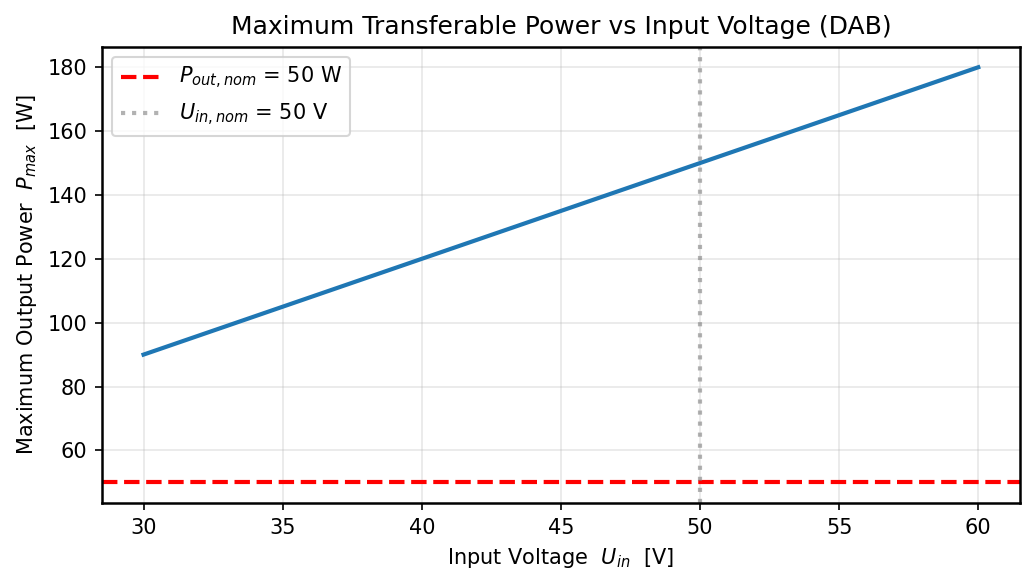

In [5]:
# Input voltage sweep
U_in = np.linspace(U_in_min, U_in_max, 300)

# Maximum transferable power
P_max = (n * U_in * U_out) / (8 * f_sw * L)

# --- Plot ---
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(U_in, P_max, linewidth=2)
ax.axhline(P_out_nom, color="r", linestyle="--", label=f"$P_{{out,nom}}$ = {P_out_nom} W")
ax.axvline(U_in_nom, color="gray", linestyle=":", alpha=0.6, label=f"$U_{{in,nom}}$ = {U_in_nom} V")
ax.set_xlabel("Input Voltage  $U_{in}$  [V]")
ax.set_ylabel("Maximum Output Power  $P_{max}$  [W]")
ax.set_title("Maximum Transferable Power vs Input Voltage (DAB)")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## 4 — Phase Shift for Nominal Power

The power transfer equation for single-phase-shift (SPS) modulation is:

$$P = \frac{n \, U_\mathrm{in} \, U_\mathrm{out} \, \phi \, (\pi - |\phi|)}{2 \pi^2 f_\mathrm{sw} \, L}$$

To find the phase shift $\phi$ required to deliver $P_\mathrm{out,nom}$ at a given $U_\mathrm{in}$, we rearrange into a quadratic in $\phi$ (for $\phi > 0$):

$$\phi^2 - \pi\,\phi + \frac{2\pi^2 f_\mathrm{sw} L \, P_\mathrm{out,nom}}{n \, U_\mathrm{in} \, U_\mathrm{out}} = 0$$

Solving (taking the smaller root for normal operation, $0 < \phi < \pi/2$):

$$\phi = \frac{\pi}{2}\left(1 - \sqrt{1 - \frac{8\,f_\mathrm{sw}\,L\,P_\mathrm{out,nom}}{n\,U_\mathrm{in}\,U_\mathrm{out}}}\right)$$

In [6]:
def phase_shift_for_power(P, U_in, U_out, n, f_sw, L):
    """
    Compute the SPS phase shift φ [rad] required to transfer power P.
    
    P = n * U_in * U_out * φ * (π - |φ|) / (2π² f_sw L)
    
    Returns the smaller root (normal operating region, 0 < φ < π/2).
    """
    discriminant = 1 - (8 * f_sw * L * P) / (n * U_in * U_out)
    if np.any(discriminant < 0):
        raise ValueError("Required power exceeds maximum transferable power for given U_in.")
    return (np.pi / 2) * (1 - np.sqrt(discriminant))


# --- Phase shifts at the three key operating points ---
phi_nom = phase_shift_for_power(P_out_nom, U_in_nom, U_out, n, f_sw, L)
phi_min = phase_shift_for_power(P_out_nom, U_in_min, U_out, n, f_sw, L)
phi_max = phase_shift_for_power(P_out_nom, U_in_max, U_out, n, f_sw, L)

print("Phase shifts to deliver P_out,nom = {:.0f} W:".format(P_out_nom))
print(f"  φ(U_in,min = {U_in_min} V) = {phi_min:.4f} rad  = {np.degrees(phi_min):.2f}°")
print(f"  φ(U_in,nom = {U_in_nom} V) = {phi_nom:.4f} rad  = {np.degrees(phi_nom):.2f}°")
print(f"  φ(U_in,max = {U_in_max} V) = {phi_max:.4f} rad  = {np.degrees(phi_max):.2f}°")

Phase shifts to deliver P_out,nom = 50 W:
  φ(U_in,min = 30 V) = 0.5236 rad  = 30.00°
  φ(U_in,nom = 50 V) = 0.2882 rad  = 16.52°
  φ(U_in,max = 60 V) = 0.2359 rad  = 13.51°


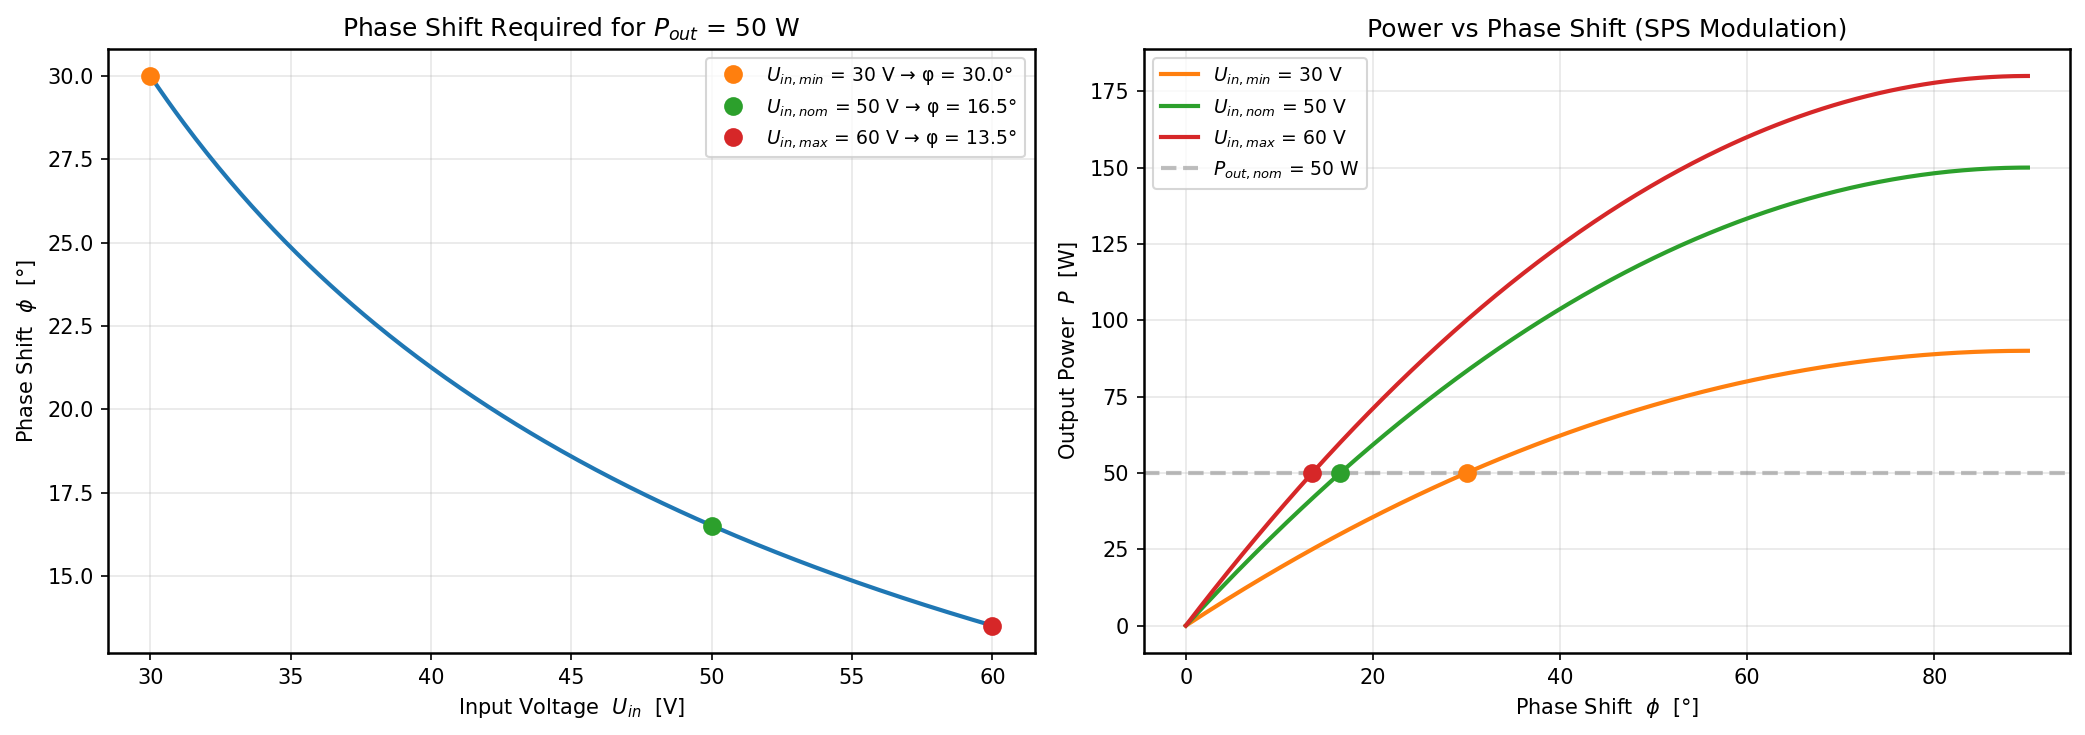

In [7]:
# --- Phase shift vs Input Voltage (at P = P_out,nom) ---
U_in_sweep = np.linspace(U_in_min, U_in_max, 300)
phi_sweep  = phase_shift_for_power(P_out_nom, U_in_sweep, U_out, n, f_sw, L)

# --- Power vs Phase shift (at the three key voltages) ---
phi_range = np.linspace(0, np.pi/2, 300)

P_at_Vmin = (n * U_in_min * U_out * phi_range * (np.pi - phi_range)) / (2 * np.pi**2 * f_sw * L)
P_at_Vnom = (n * U_in_nom * U_out * phi_range * (np.pi - phi_range)) / (2 * np.pi**2 * f_sw * L)
P_at_Vmax = (n * U_in_max * U_out * phi_range * (np.pi - phi_range)) / (2 * np.pi**2 * f_sw * L)

# ===================== PLOTS =====================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Phase shift required vs U_in ---
ax1 = axes[0]
ax1.plot(U_in_sweep, np.degrees(phi_sweep), linewidth=2, color="tab:blue")

# Mark the three key operating points
for U, phi, color, label in [
    (U_in_min, phi_min, "tab:orange", f"$U_{{in,min}}$ = {U_in_min} V → φ = {np.degrees(phi_min):.1f}°"),
    (U_in_nom, phi_nom, "tab:green",  f"$U_{{in,nom}}$ = {U_in_nom} V → φ = {np.degrees(phi_nom):.1f}°"),
    (U_in_max, phi_max, "tab:red",    f"$U_{{in,max}}$ = {U_in_max} V → φ = {np.degrees(phi_max):.1f}°"),
]:
    ax1.plot(U, np.degrees(phi), "o", color=color, markersize=8, zorder=5, label=label)

ax1.set_xlabel("Input Voltage  $U_{in}$  [V]")
ax1.set_ylabel("Phase Shift  $\\phi$  [°]")
ax1.set_title(f"Phase Shift Required for $P_{{out}}$ = {P_out_nom} W")
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# --- Right: Power vs Phase shift at each key voltage ---
ax2 = axes[1]
ax2.plot(np.degrees(phi_range), P_at_Vmin, linewidth=2, color="tab:orange", label=f"$U_{{in,min}}$ = {U_in_min} V")
ax2.plot(np.degrees(phi_range), P_at_Vnom, linewidth=2, color="tab:green",  label=f"$U_{{in,nom}}$ = {U_in_nom} V")
ax2.plot(np.degrees(phi_range), P_at_Vmax, linewidth=2, color="tab:red",    label=f"$U_{{in,max}}$ = {U_in_max} V")

# Mark operating points
ax2.plot(np.degrees(phi_min), P_out_nom, "o", color="tab:orange", markersize=8, zorder=5)
ax2.plot(np.degrees(phi_nom), P_out_nom, "o", color="tab:green",  markersize=8, zorder=5)
ax2.plot(np.degrees(phi_max), P_out_nom, "o", color="tab:red",    markersize=8, zorder=5)

ax2.axhline(P_out_nom, color="gray", linestyle="--", alpha=0.5, label=f"$P_{{out,nom}}$ = {P_out_nom} W")

ax2.set_xlabel("Phase Shift  $\\phi$  [°]")
ax2.set_ylabel("Output Power  $P$  [W]")
ax2.set_title("Power vs Phase Shift (SPS Modulation)")
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

## 5 — Output Current, Waveforms & Output Capacitor

### 5.1 — Output DC Current

$$I_\mathrm{out} = \frac{P_\mathrm{out,nom}}{U_\mathrm{out}}$$

### 5.2 — Inductor Currents $I_1$ and $I_2$

From the course slides, the inductor current at the secondary switching instant ($\theta = \phi$) and at the primary switching instant ($\theta = \pi$) are:

$$I_1 = \frac{V_1}{2\omega L}\left(2\phi - \left(1 - n\frac{V_2}{V_1}\right)\pi\right)$$

$$I_2 = \frac{V_1}{2\omega L}\left(2\,n\frac{V_2}{V_1}\,\phi + \left(1 - n\frac{V_2}{V_1}\right)\pi\right)$$

where $V_1 = U_\mathrm{in,min}$, $V_2 = U_\mathrm{out}$, and $\phi = \phi_\mathrm{min}$.

In [8]:
# === Question 1: Output DC current at nominal power ===
I_out = P_out_nom / U_out
print(f"Output DC current  I_out = P_out / U_out = {P_out_nom} / {U_out} = {I_out:.4f} A")

# === Question 2: I_1 and I_2 at nominal power & lowest input voltage ===
omega = 2 * np.pi * f_sw

V1  = U_in_min   # Primary voltage (worst case)
V2  = U_out      # Secondary voltage
phi = phi_min    # Phase shift required at U_in_min

d = n * V2 / V1  # Voltage conversion ratio referred to primary

I_1 = 0.5 * (2 * phi - (1 - d) * np.pi) * V1 / (omega * L)
I_2 = 0.5 * (2 * d * phi + (1 - d) * np.pi) * V1 / (omega * L)

print(f"\nAt U_in = U_in_min = {U_in_min} V,  φ = {np.degrees(phi):.2f}°:")
print(f"  d  = n·U_out/U_in = {d:.4f}")
print(f"  I₁ = {I_1:.4f} A   (inductor current at θ = φ)")
print(f"  I₂ = {I_2:.4f} A   (inductor current at θ = π)")

Output DC current  I_out = P_out / U_out = 50 / 12 = 4.1667 A

At U_in = U_in_min = 30 V,  φ = 30.00°:
  d  = n·U_out/U_in = 1.6667
  I₁ = 3.6000 A   (inductor current at θ = φ)
  I₂ = -0.4000 A   (inductor current at θ = π)


### 5.3 — Inductor Current Waveform $i_L(\theta)$

The inductor current (referred to the primary side) is piecewise-linear over one switching period.  
Key values at the switching instants:

| $\theta$ | $i_L$ |
|---|---|
| $0$ | $-I_2$ |
| $\phi$ | $I_1$ |
| $\pi$ | $I_2$ |
| $\pi+\phi$ | $-I_1$ |
| $2\pi$ | $-I_2$ |

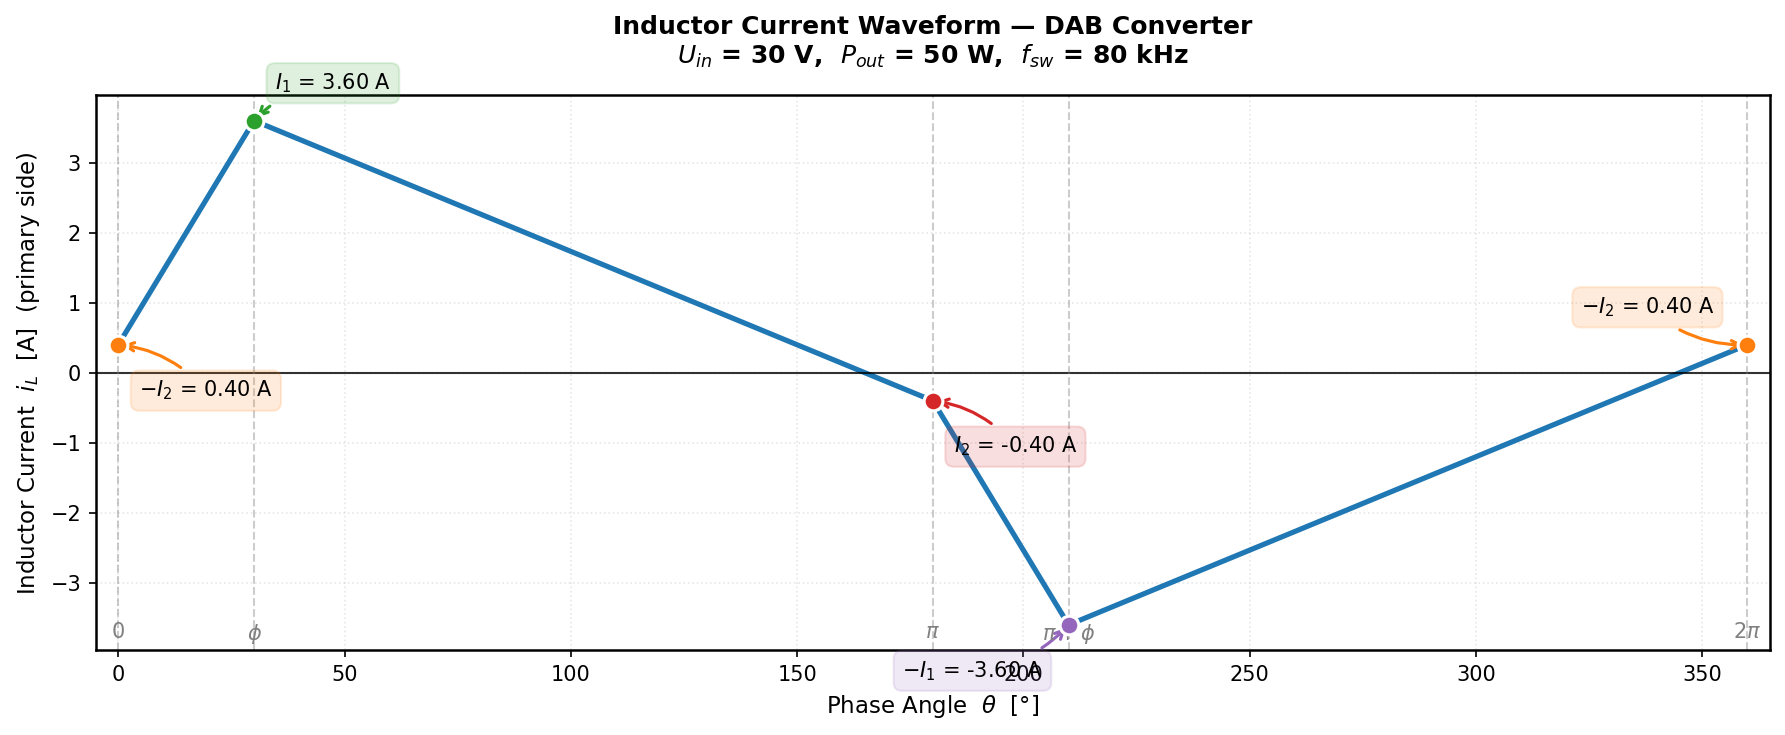

In [9]:
# === Question 3: Inductor current waveform i_L(θ) for one period ===

# Key angular points and corresponding inductor current values
theta_pts = np.array([0, phi, np.pi, np.pi + phi, 2 * np.pi])
iL_pts    = np.array([-I_2, I_1, I_2, -I_1, -I_2])

# Fine grid for plotting
theta = np.linspace(0, 2 * np.pi, 2000)
i_L   = np.interp(theta, theta_pts, iL_pts)

# --- Enhanced Plot ---
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(np.degrees(theta), i_L, linewidth=2.5, color="#1f77b4", antialiased=True)
ax.axhline(0, color="k", linewidth=1, alpha=0.8)

# Mark the key points with enhanced styling
marker_colors = ["#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#ff7f0e"]
annotation_offsets = [(10, -25), (10, 15), (10, -25), (-80, -25), (-80, 15)]

for th, iL_val, lbl, color, offset in zip(theta_pts, iL_pts,
                           [r"$-I_2$", r"$I_1$", r"$I_2$", r"$-I_1$", r"$-I_2$"],
                           marker_colors, annotation_offsets):
    ax.plot(np.degrees(th), iL_val, "o", color=color, markersize=9, 
            markeredgecolor="white", markeredgewidth=1.5, zorder=5)
    ax.annotate(f"{lbl} = {iL_val:.2f} A", (np.degrees(th), iL_val),
                textcoords="offset points", xytext=offset, fontsize=10,
                bbox=dict(boxstyle="round,pad=0.4", facecolor=color, alpha=0.15, edgecolor=color, linewidth=1),
                arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=0.2", 
                               color=color, linewidth=1.5))

# Vertical lines at switching instants with labels
switch_labels = [(0, r"$0$"), (phi, r"$\phi$"), (np.pi, r"$\pi$"),
                 (np.pi + phi, r"$\pi+\phi$"), (2*np.pi, r"$2\pi$")]
for th, lbl in switch_labels:
    ax.axvline(np.degrees(th), color="gray", linestyle="--", alpha=0.4, linewidth=1)
    ax.text(np.degrees(th), ax.get_ylim()[0] * 0.9, lbl, 
            ha="center", va="top", fontsize=10, color="gray")

ax.set_xlabel(r"Phase Angle  $\theta$  [°]", fontsize=11, fontweight="medium")
ax.set_ylabel(r"Inductor Current  $i_L$  [A]  (primary side)", fontsize=11, fontweight="medium")
ax.set_title(f"Inductor Current Waveform — DAB Converter\n$U_{{in}}$ = {U_in_min} V,  $P_{{out}}$ = {P_out_nom} W,  $f_{{sw}}$ = {f_sw/1e3:.0f} kHz", 
             fontsize=12, fontweight="bold", pad=15)
ax.grid(True, alpha=0.3, linestyle=":", linewidth=0.8)
ax.set_xlim(-5, 365)
fig.tight_layout()
plt.show()

### 5.4 — Secondary Full-Bridge Output Current $i_{FB,out}(\theta)$

The secondary full-bridge switching function is:

$$s_2(\theta) = \begin{cases} -1 & 0 \le \theta < \phi \\ +1 & \phi \le \theta < \pi+\phi \\ -1 & \pi+\phi \le \theta < 2\pi \end{cases}$$

The DC-side output current of the secondary bridge is:

$$i_\mathrm{FB,out}(\theta) = s_2(\theta) \cdot n \cdot i_L(\theta)$$

Average i_FB_out = 4.1588 A   (should be ≈ I_out = 4.1667 A)


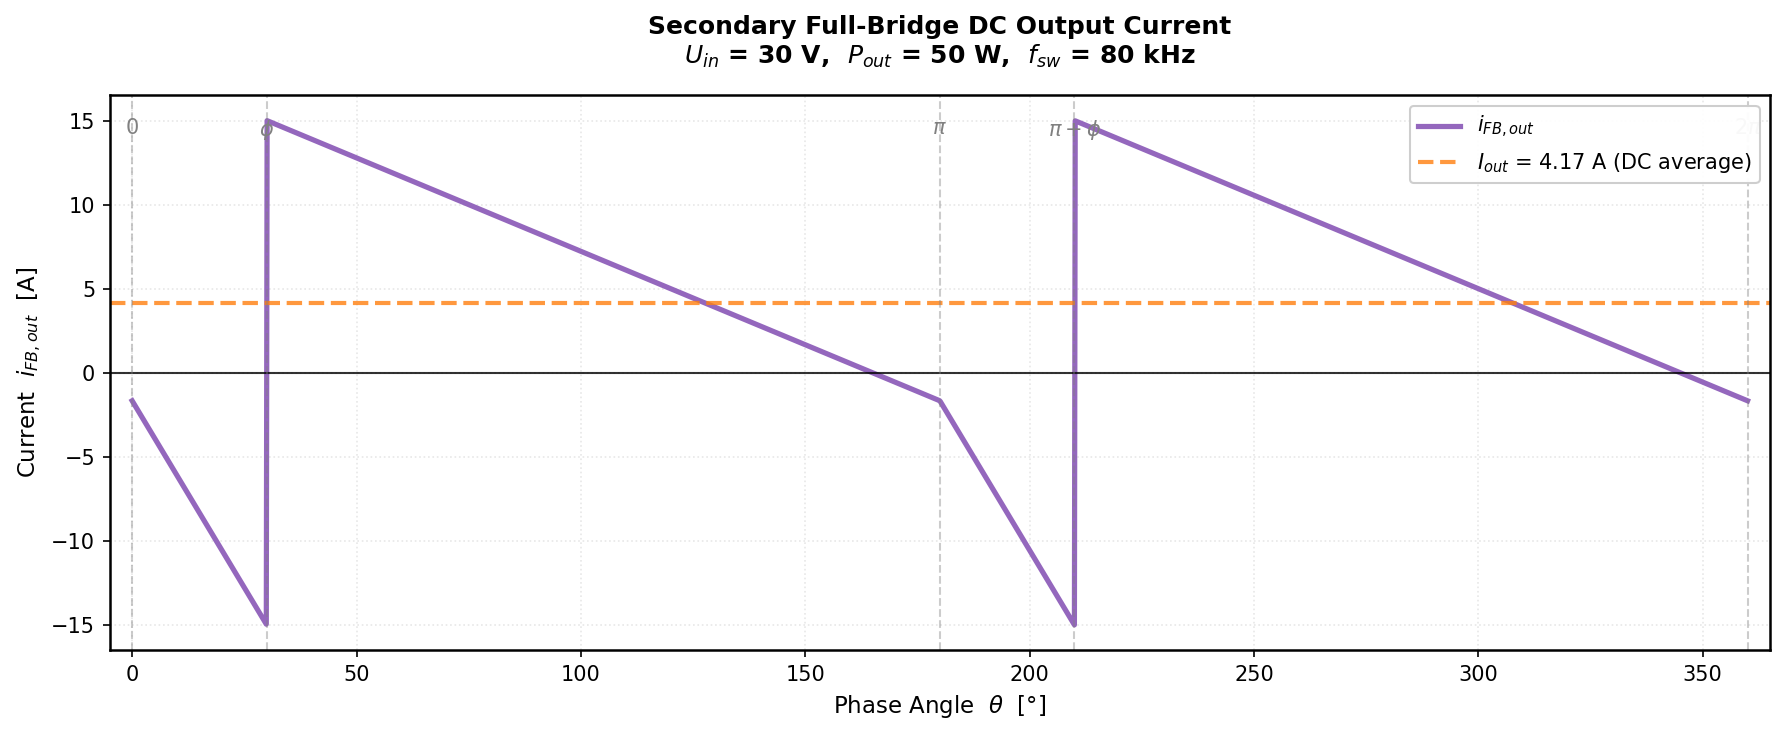

In [10]:
# === Question 4: Output current of secondary-side full bridge ===

# Switching function s2(θ)
s2 = np.ones_like(theta)
s2[theta < phi] = -1
s2[theta >= (np.pi + phi)] = -1

# Secondary-side DC output current  (secondary winding current = n * i_L)
i_FB_out = s2 * n * i_L

# Verify: average should equal I_out
I_out_check = np.mean(i_FB_out)
print(f"Average i_FB_out = {I_out_check:.4f} A   (should be ≈ I_out = {I_out:.4f} A)")

# --- Enhanced Plot ---
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(np.degrees(theta), i_FB_out, linewidth=2.5, color="#9467bd", antialiased=True, label=r"$i_{FB,out}$")
ax.axhline(I_out, color="#ff7f0e", linestyle="--", linewidth=2, alpha=0.8,
           label=f"$I_{{out}}$ = {I_out:.2f} A (DC average)")
ax.axhline(0, color="k", linewidth=1, alpha=0.8)

# Switching instants
for th, lbl in [(0, r"$0$"), (phi, r"$\phi$"), (np.pi, r"$\pi$"),
                (np.pi + phi, r"$\pi+\phi$"), (2*np.pi, r"$2\pi$")]:
    ax.axvline(np.degrees(th), color="gray", linestyle="--", alpha=0.4, linewidth=1)
    y_pos = ax.get_ylim()[1] * 0.92
    ax.text(np.degrees(th), y_pos, lbl, ha="center", va="top", fontsize=10, color="gray")

ax.set_xlabel(r"Phase Angle  $\theta$  [°]", fontsize=11, fontweight="medium")
ax.set_ylabel(r"Current  $i_{FB,out}$  [A]", fontsize=11, fontweight="medium")
ax.set_title(f"Secondary Full-Bridge DC Output Current\n$U_{{in}}$ = {U_in_min} V,  $P_{{out}}$ = {P_out_nom} W,  $f_{{sw}}$ = {f_sw/1e3:.0f} kHz",
             fontsize=12, fontweight="bold", pad=15)
ax.legend(fontsize=10, loc="upper right", framealpha=0.95)
ax.grid(True, alpha=0.3, linestyle=":", linewidth=0.8)
ax.set_xlim(-5, 365)
fig.tight_layout()
plt.show()

### 5.5 — Capacitor Ripple Current, Ripple Charge & $C_{out}$

The capacitor current is:

$$\Delta i = i_\mathrm{FB,out} - I_\mathrm{out}$$

The ripple charge causing the output voltage ripple is the integral of the **positive** portion (capacitor charging phase):

$$\Delta Q = \int_{\Delta i > 0} \Delta i \, dt$$

The required output capacitance is then:

$$C_\mathrm{out} = \frac{\Delta Q}{\Delta U_\mathrm{out,pp}}$$

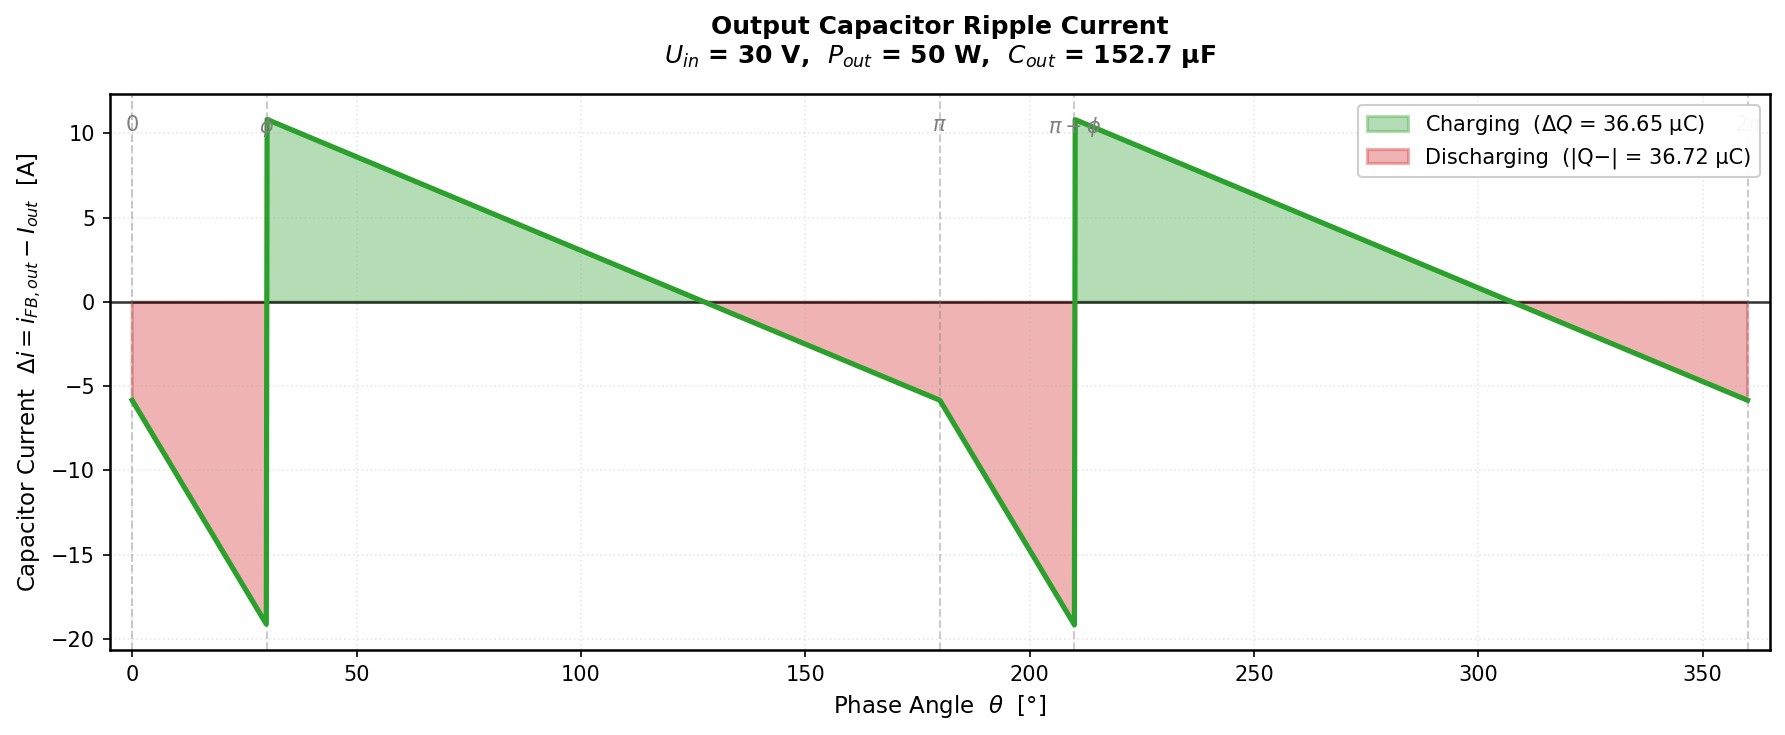

Ripple charge  ΔQ = 36.6528 µC
Output capacitance  C_out = ΔQ / ΔU_pp = 36.6528 µC / 240 mV = 152.72 µF = 1.527198e-04 F


In [11]:
# === Question 5: Δi = i_FB_out − I_out ===
delta_i = i_FB_out - I_out

# Time base and charge/discharge quantities (needed for plot labels)
t = theta / omega   # Convert angle to time [s]
Q_charge = np.trapezoid(np.maximum(delta_i, 0), t)
Q_discharge = np.trapezoid(np.minimum(delta_i, 0), t)   # negative value
C_out_est = Q_charge / dU_out_pp

# --- Enhanced Plot ---
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(np.degrees(theta), delta_i, linewidth=2.5, color="#2ca02c", antialiased=True, zorder=3)
ax.fill_between(np.degrees(theta), delta_i, 0,
                where=(delta_i > 0), alpha=0.35, color="#2ca02c", 
                label=r"Charging  ($\Delta Q$ = {:.2f} µC)".format(Q_charge*1e6), edgecolor="#2ca02c", linewidth=1.5)
ax.fill_between(np.degrees(theta), delta_i, 0,
                where=(delta_i < 0), alpha=0.35, color="#d62728", 
                label="Discharging  (|Q−| = {:.2f} µC)".format(abs(Q_discharge)*1e6), edgecolor="#d62728", linewidth=1.5)
ax.axhline(0, color="k", linewidth=1.2, alpha=0.8, zorder=2)

# Switching instants
for th, lbl in [(0, r"$0$"), (phi, r"$\phi$"), (np.pi, r"$\pi$"),
                (np.pi + phi, r"$\pi+\phi$"), (2*np.pi, r"$2\pi$")]:
    ax.axvline(np.degrees(th), color="gray", linestyle="--", alpha=0.4, linewidth=1)
    y_pos = ax.get_ylim()[1] * 0.9
    ax.text(np.degrees(th), y_pos, lbl, ha="center", va="top", fontsize=10, color="gray")

ax.set_xlabel(r"Phase Angle  $\theta$  [°]", fontsize=11, fontweight="medium")
ax.set_ylabel(r"Capacitor Current  $\Delta i = i_{FB,out} - I_{out}$  [A]", fontsize=11, fontweight="medium")
ax.set_title(f"Output Capacitor Ripple Current\n$U_{{in}}$ = {U_in_min} V,  $P_{{out}}$ = {P_out_nom} W,  $C_{{out}}$ = {C_out_est*1e6:.1f} µF",
             fontsize=12, fontweight="bold", pad=15)
ax.legend(fontsize=10, loc="upper right", framealpha=0.95)
ax.grid(True, alpha=0.3, linestyle=":", linewidth=0.8)
ax.set_xlim(-5, 365)
fig.tight_layout()
plt.show()

# === Question 6: Ripple charge ΔQ ===
delta_Q = Q_charge
print(f"Ripple charge  ΔQ = {delta_Q*1e6:.4f} µC")

# === Question 7: Output capacitance ===
C_out = delta_Q / dU_out_pp
print(f"Output capacitance  C_out = ΔQ / ΔU_pp = {delta_Q*1e6:.4f} µC / {dU_out_pp*1e3:.0f} mV = {C_out*1e6:.2f} µF = {C_out:.6e} F")

In [12]:
# === Verify: charge == discharge over one period (steady-state condition) ===
Q_charge    = np.trapezoid(np.maximum(delta_i, 0), t)
Q_discharge = np.trapezoid(np.minimum(delta_i, 0), t)   # negative value

print(f"Charge (Δi > 0):     Q+ = {Q_charge*1e6:.4f} µC")
print(f"Discharge (Δi < 0):  Q− = {Q_discharge*1e6:.4f} µC")
print(f"Sum Q+ + Q−:              = {(Q_charge + Q_discharge)*1e6:.4f} µC")
print(f"\n→ |Q+| ≈ |Q−|?  Ratio = {abs(Q_charge / Q_discharge):.6f}  (should be 1.0)")

Charge (Δi > 0):     Q+ = 36.6528 µC
Discharge (Δi < 0):  Q− = -36.7153 µC
Sum Q+ + Q−:              = -0.0625 µC

→ |Q+| ≈ |Q−|?  Ratio = 0.998297  (should be 1.0)



## Q8 — DC Blocking Capacitor

To avoid DC bias in the transformer magnetizing path, a **DC blocking capacitor** is added in series with the transformer primary winding.

$$C_{\mathrm{DCblock,min}} = \frac{100}{4\pi^2 f_{\mathrm{sw}}^2 L}$$

which corresponds to 10 times the resonant capacitance of the transformer inductance at the switching frequency

This ensures the capacitive reactance at the switching frequency is sufficiently small to avoid excessive voltage drop while maintaining adequate DC blocking.


In [13]:
# === Question 8: DC Blocking Capacitor ===

# Using the provided equation for minimum DC blocking capacitance
C_DCblock_min = 100 / (4 * np.pi**2 * f_sw**2 * L)

print(f"Minimum DC blocking capacitance:")
print(f"  C_DCblock,min = 100 / (4π² f_sw² L)")
print(f"                = 100 / (4π² × ({f_sw:.0f})² × {L:.6e})")
print(f"                = {C_DCblock_min*1e6:.2f} µF")
print(f"                = {C_DCblock_min:.6e} F")

# Practical consideration: choose a standard value slightly higher
C_DCblock_practical = np.ceil(C_DCblock_min * 1e6 / 10) * 10  # Round up to nearest 10 µF
print(f"\nPractical choice: C_DCblock ≥ {C_DCblock_practical:.0f} µF = {C_DCblock_practical*1e-6:.6e} F")

Minimum DC blocking capacitance:
  C_DCblock,min = 100 / (4π² f_sw² L)
                = 100 / (4π² × (80000)² × 2.604167e-05)
                = 15.20 µF
                = 1.519818e-05 F

Practical choice: C_DCblock ≥ 20 µF = 2.000000e-05 F


(I took C_DCblock = 1.519818e-05  for the PLECS simulation)

## Q9 — Input Capacitance
### Q9.1: Input Capacitance defined by voltage ripple, $C_{in,\mathrm{ripple}}$

Consider a $2\%$ input-voltage ripple tolerance, similarly to the method used in Q5.

The ideal DC input current at the worst-case input voltage is:
$$I_{\mathrm{in}} = \frac{P_{\mathrm{out,nom}}}{U_{\mathrm{in,min}}}$$

The pulsating current drawn by the primary full-bridge is:
$$i_{\mathrm{FB,pri}}(\theta) = s_1(\theta)\,i_L(\theta),\quad
s_1(\theta)=\begin{cases}+1,&0\le\theta<\pi\\-1,&\pi\le\theta<2\pi\end{cases}$$

The input capacitor current is then:
$$i_{C_{in}}(\theta)=I_{\mathrm{in}}-i_{\mathrm{FB,pri}}(\theta)$$

Using the positive (charging) portion of $i_{C_{in}}$,
$$\Delta Q_{in}=\int_{i_{C_{in}}>0} i_{C_{in}}\,dt$$

with $\Delta U_{in,pp}=0.02\,U_{in,min}$, the required capacitance is
$$C_{in,\mathrm{ripple}}=\frac{\Delta Q_{in}}{\Delta U_{in,pp}}$$

In [14]:
# === Question 9.1: Input ripple-based capacitance ===

# Worst-case DC input current (ideal, neglecting losses)
I_in = P_out_nom / U_in_min

# Primary full-bridge switching function s1(θ)
s1 = np.ones_like(theta)
s1[theta >= np.pi] = -1

# Pulsating current drawn by primary bridge (primary-referred current)
i_FB_pri = s1 * i_L

# Consistency check: average bridge input current vs DC input current
I_in_check = np.mean(i_FB_pri)
print(f"DC input current (worst case):      I_in       = {I_in:.4f} A")
print(f"Average primary bridge current:      <i_FB_pri> = {I_in_check:.4f} A")
print(f"Difference <i_FB_pri> - I_in:                    = {I_in_check - I_in:.4e} A")

# Input capacitor ripple-current model
i_Cin = I_in - i_FB_pri

# 2% allowable input-voltage ripple (peak-to-peak)
dU_in_rel = 0.02
dU_in_pp  = dU_in_rel * U_in_min

# Charge/discharge over one switching period
Q_in_charge    = np.trapezoid(np.maximum(i_Cin, 0), t)
Q_in_discharge = np.trapezoid(np.minimum(i_Cin, 0), t)

# Required input capacitance from ripple constraint
C_in_ripple = Q_in_charge / dU_in_pp

print(f"\nInput ripple specification:          ΔU_in,pp   = {dU_in_pp:.4f} V ({dU_in_rel*100:.1f}%)")
print(f"Charge (i_Cin > 0):                  Q_in,+     = {Q_in_charge*1e6:.4f} µC")
print(f"Discharge (i_Cin < 0):               Q_in,-     = {Q_in_discharge*1e6:.4f} µC")
print(f"Required capacitance:                C_in,ripple= {C_in_ripple*1e6:.2f} µF = {C_in_ripple:.6e} F")

DC input current (worst case):      I_in       = 1.6667 A
Average primary bridge current:      <i_FB_pri> = 1.6658 A
Difference <i_FB_pri> - I_in:                    = -8.3375e-04 A

Input ripple specification:          ΔU_in,pp   = 0.6000 V (2.0%)
Charge (i_Cin > 0):                  Q_in,+     = 6.0836 µC
Discharge (i_Cin < 0):               Q_in,-     = -6.0836 µC
Required capacitance:                C_in,ripple= 10.14 µF = 1.013938e-05 F


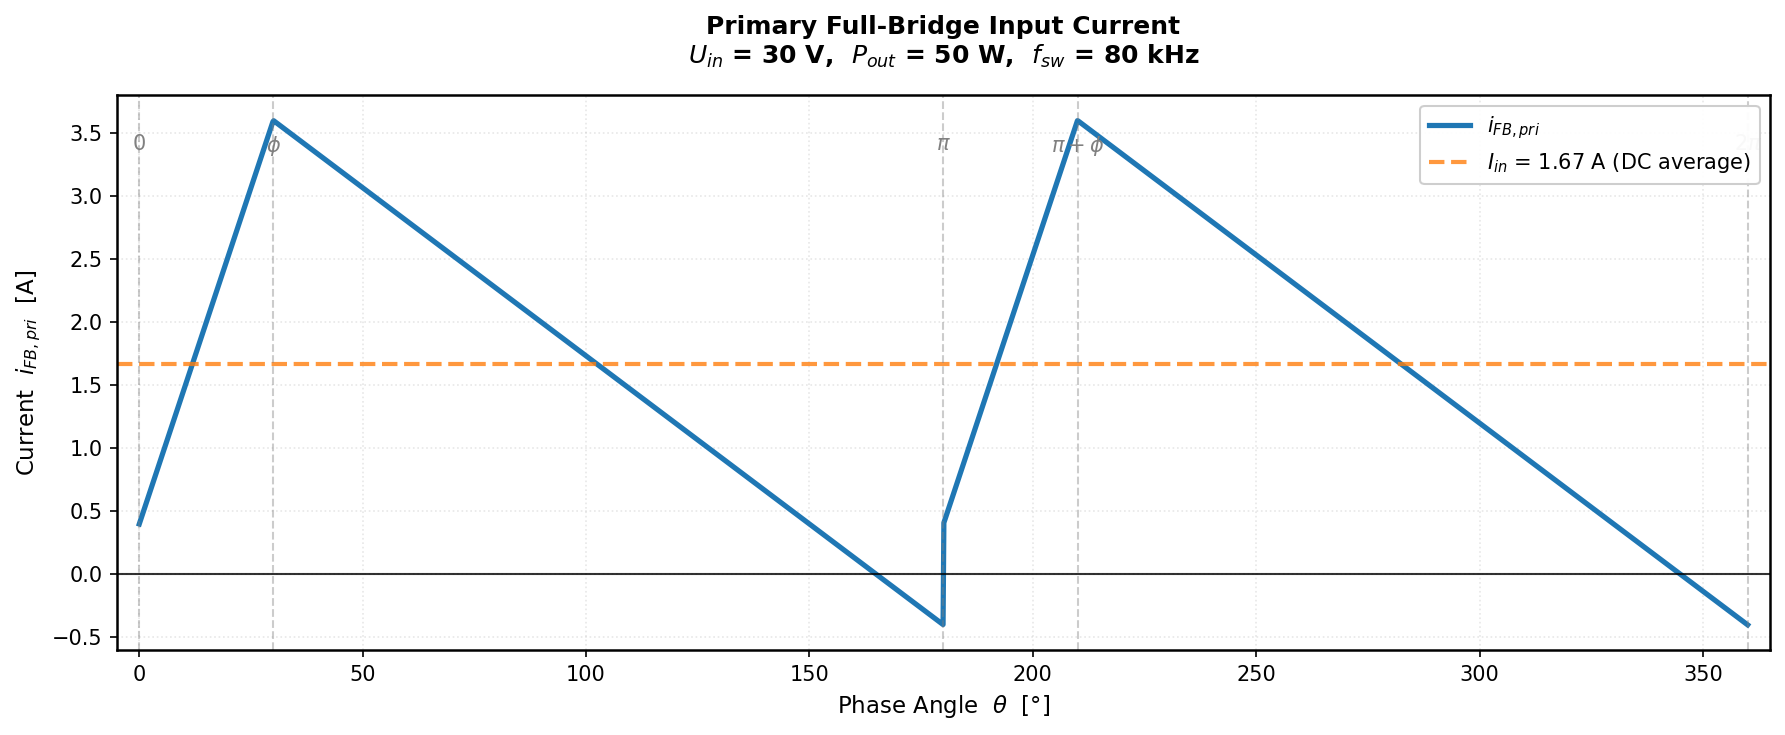

In [15]:
# === Plot: Primary full-bridge input current ===

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(np.degrees(theta), i_FB_pri, linewidth=2.5, color="#1f77b4", antialiased=True, label=r"$i_{FB,pri}$")
ax.axhline(I_in, color="#ff7f0e", linestyle="--", linewidth=2, alpha=0.8,
           label=f"$I_{{in}}$ = {I_in:.2f} A (DC average)")
ax.axhline(0, color="k", linewidth=1, alpha=0.8)

# Switching instants
for th, lbl in [(0, r"$0$"), (phi, r"$\phi$"), (np.pi, r"$\pi$"),
                (np.pi + phi, r"$\pi+\phi$"), (2*np.pi, r"$2\pi$")]:
    ax.axvline(np.degrees(th), color="gray", linestyle="--", alpha=0.4, linewidth=1)
    y_pos = ax.get_ylim()[1] * 0.92
    ax.text(np.degrees(th), y_pos, lbl, ha="center", va="top", fontsize=10, color="gray")

ax.set_xlabel(r"Phase Angle  $\theta$  [°]", fontsize=11, fontweight="medium")
ax.set_ylabel(r"Current  $i_{FB,pri}$  [A]", fontsize=11, fontweight="medium")
ax.set_title(f"Primary Full-Bridge Input Current\n$U_{{in}}$ = {U_in_min} V,  $P_{{out}}$ = {P_out_nom} W,  $f_{{sw}}$ = {f_sw/1e3:.0f} kHz",
             fontsize=12, fontweight="bold", pad=15)
ax.legend(fontsize=10, loc="upper right", framealpha=0.95)
ax.grid(True, alpha=0.3, linestyle=":", linewidth=0.8)
ax.set_xlim(-5, 365)
fig.tight_layout()
plt.show()

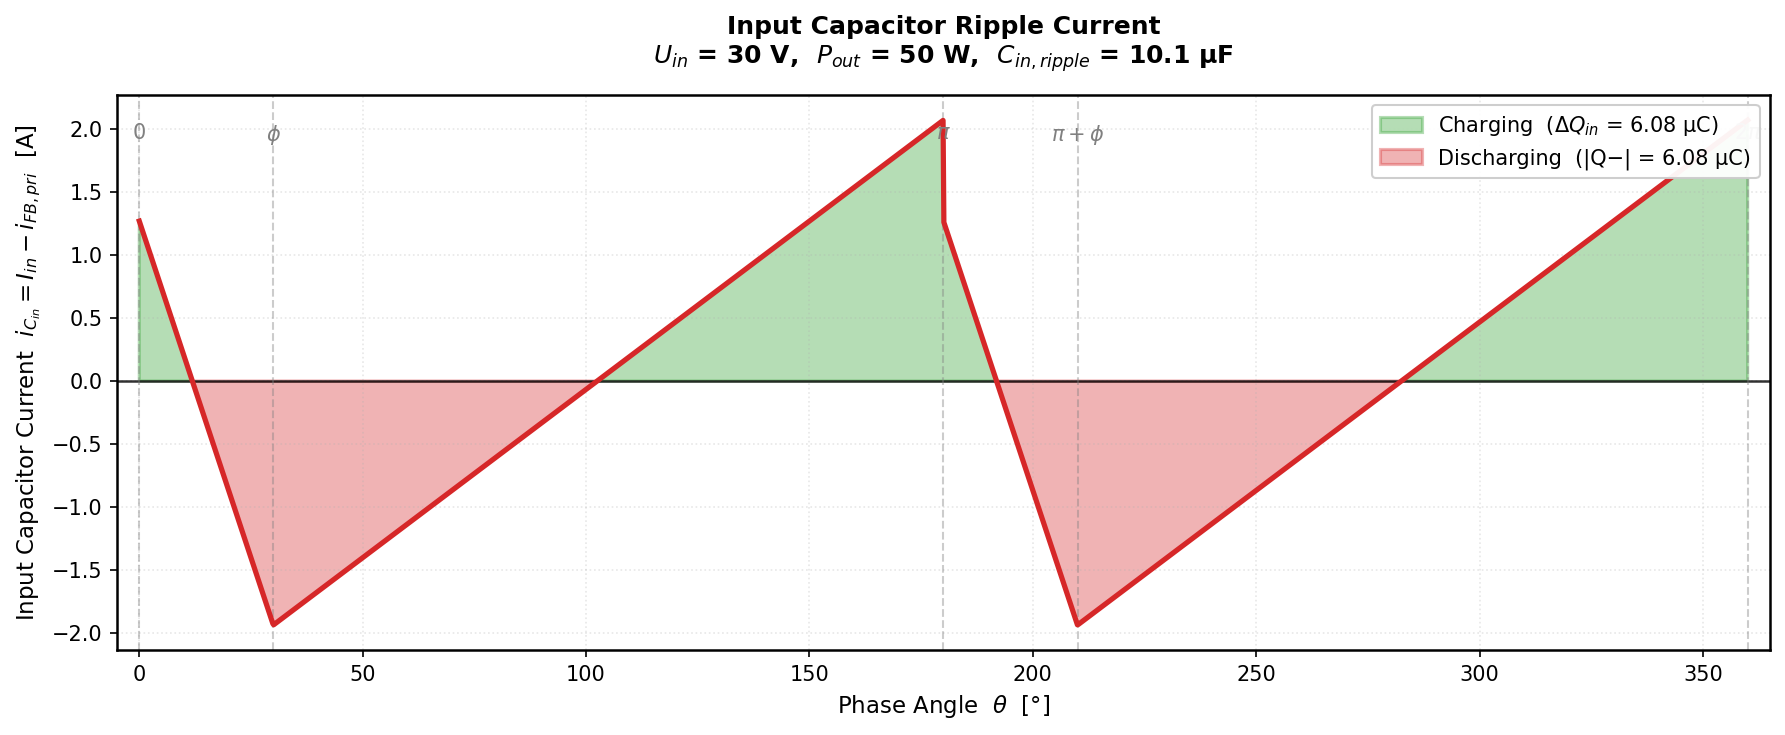

In [16]:
# === Plot: Input capacitor ripple current ===

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(np.degrees(theta), i_Cin, linewidth=2.5, color="#d62728", antialiased=True, zorder=3)
ax.fill_between(np.degrees(theta), i_Cin, 0,
                where=(i_Cin > 0), alpha=0.35, color="#2ca02c", 
                label=r"Charging  ($\Delta Q_{{in}}$ = {:.2f} µC)".format(Q_in_charge*1e6), edgecolor="#2ca02c", linewidth=1.5)
ax.fill_between(np.degrees(theta), i_Cin, 0,
                where=(i_Cin < 0), alpha=0.35, color="#d62728", 
                label="Discharging  (|Q−| = {:.2f} µC)".format(abs(Q_in_discharge)*1e6), edgecolor="#d62728", linewidth=1.5)
ax.axhline(0, color="k", linewidth=1.2, alpha=0.8, zorder=2)

# Switching instants
for th, lbl in [(0, r"$0$"), (phi, r"$\phi$"), (np.pi, r"$\pi$"),
                (np.pi + phi, r"$\pi+\phi$"), (2*np.pi, r"$2\pi$")]:
    ax.axvline(np.degrees(th), color="gray", linestyle="--", alpha=0.4, linewidth=1)
    y_pos = ax.get_ylim()[1] * 0.9
    ax.text(np.degrees(th), y_pos, lbl, ha="center", va="top", fontsize=10, color="gray")

ax.set_xlabel(r"Phase Angle  $\theta$  [°]", fontsize=11, fontweight="medium")
ax.set_ylabel(r"Input Capacitor Current  $i_{{C_{{in}}}} = I_{{in}} - i_{{FB,pri}}$  [A]", fontsize=11, fontweight="medium")
ax.set_title(f"Input Capacitor Ripple Current\n$U_{{{{in}}}}$ = {U_in_min} V,  $P_{{{{out}}}}$ = {P_out_nom} W,  $C_{{{{in,ripple}}}}$ = {C_in_ripple*1e6:.1f} µF",
             fontsize=12, fontweight="bold", pad=15)
ax.legend(fontsize=10, loc="upper right", framealpha=0.95)
ax.grid(True, alpha=0.3, linestyle=":", linewidth=0.8)
ax.set_xlim(-5, 365)
fig.tight_layout()
plt.show()

### Q9.2: Input capacitance defined by hold-up time, $C_{in,\mathrm{hold\text{-}up}}$

#### Energy Balance

The energy discharged from the input capacitor during hold-up must equal the energy consumed by the converter:

$$\Delta E = \frac{1}{2}C_{in,\mathrm{hold\text{-}up}}\left(U_{\mathrm{in,nom}}^2 - U_{\mathrm{in,min}}^2\right) = P_{\mathrm{out,nom}} \cdot t_{\mathrm{holdup}}$$

Solving for the required capacitance:

$$C_{in,\mathrm{hold\text{-}up}} = \frac{2\,P_{\mathrm{out,nom}}\,t_{\mathrm{holdup}}}{U_{\mathrm{in,nom}}^2 - U_{\mathrm{in,min}}^2}$$

In [17]:
# === Question 9.2: Input hold-up capacitance ===

# Hold-up time for half-cycle grid interruption (50 Hz grid)
t_holdup = 10e-3  # [s] = 10 ms

# Energy balance: Energy discharged from capacitor = Energy consumed by load
# 0.5 * C * (U_in_nom^2 - U_in_min^2) = P_out_nom * t_holdup
# Solve for C:
C_in_holdup = (2 * P_out_nom * t_holdup) / (U_in_nom**2 - U_in_min**2)

# Energy stored and discharged
E_initial = 0.5 * C_in_holdup * U_in_nom**2
E_final   = 0.5 * C_in_holdup * U_in_min**2
E_discharged = E_initial - E_final
E_required = P_out_nom * t_holdup

print(f"Hold-up time requirement:           t_holdup = {t_holdup*1e3:.0f} ms")
print(f"\nVoltage drop during hold-up:")
print(f"  Initial voltage (nominal):        U_in,nom = {U_in_nom} V")
print(f"  Final voltage (minimum):          U_in,min = {U_in_min} V")
print(f"  Voltage drop:                     ΔU       = {U_in_nom - U_in_min} V")
print(f"\nEnergy analysis:")
print(f"  Energy required by load:          E_req    = P × t = {P_out_nom} W × {t_holdup*1e3:.0f} ms = {E_required:.4f} J")
print(f"  Energy discharged from capacitor: E_disch  = {E_discharged:.4f} J")
print(f"  Match check (E_disch - E_req):             = {E_discharged - E_required:.6f} J")
print(f"\nRequired hold-up capacitance:")
print(f"  C_in,holdup = 2 × P_out × t / (ΔU²)")
print(f"              = 2 × {P_out_nom} W × {t_holdup*1e3:.0f} ms / ({U_in_nom}² - {U_in_min}²)")
print(f"              = {C_in_holdup*1e6:.2f} µF")
print(f"              = {C_in_holdup:.6e} F")

# Comparison with ripple-based capacitance
print(f"\n=== Comparison ===")
print(f"C_in,ripple  = {C_in_ripple*1e6:.2f} µF  (for 2% voltage ripple)")
print(f"C_in,holdup  = {C_in_holdup*1e6:.2f} µF  (for 10 ms hold-up time)")
print(f"Ratio:         {C_in_holdup/C_in_ripple:.2f}x")


Hold-up time requirement:           t_holdup = 10 ms

Voltage drop during hold-up:
  Initial voltage (nominal):        U_in,nom = 50 V
  Final voltage (minimum):          U_in,min = 30 V
  Voltage drop:                     ΔU       = 20 V

Energy analysis:
  Energy required by load:          E_req    = P × t = 50 W × 10 ms = 0.5000 J
  Energy discharged from capacitor: E_disch  = 0.5000 J
  Match check (E_disch - E_req):             = 0.000000 J

Required hold-up capacitance:
  C_in,holdup = 2 × P_out × t / (ΔU²)
              = 2 × 50 W × 10 ms / (50² - 30²)
              = 625.00 µF
              = 6.250000e-04 F

=== Comparison ===
C_in,ripple  = 10.14 µF  (for 2% voltage ripple)
C_in,holdup  = 625.00 µF  (for 10 ms hold-up time)
Ratio:         61.64x


## Q10 — Discharge Resistor

For safety, a **discharge resistor** is placed in parallel with the input capacitor to ensure the stored energy is dissipated after shutdown.

### Required Discharge Resistance

The voltage across a capacitor during RC discharge follows:

$$U(t) = U_0 \cdot e^{-t/(RC)}$$

To discharge from 100% to 5% of rated voltage in time $t_{\mathrm{discharge}}$:

$$0.05 = e^{-t_{\mathrm{discharge}}/(RC)}$$

Taking the natural logarithm:

$$\ln(0.05) = -\frac{t_{\mathrm{discharge}}}{RC}$$

Solving for $R$:

$$R_{\mathrm{discharge}} = \frac{t_{\mathrm{discharge}}}{C_{in} \cdot |\ln(0.05)|} = \frac{t_{\mathrm{discharge}}}{C_{in} \cdot \ln(20)}$$

### Power Loss

The discharge resistor causes continuous power loss during operation. At maximum input voltage:

$$P_{\mathrm{loss,Rdischarge}} = \frac{U_{\mathrm{in,max}}^2}{R_{\mathrm{discharge}}}$$

In [18]:
# === Question 10.1: Required discharge resistance ===

# Use the hold-up capacitance as the design value
C_in_total = np.ceil(C_in_holdup * 1e6 / 100) * 100 * 1e-6  # [F] = 700 µF

# Discharge requirement: 100% → 5% in less than 60 seconds
t_discharge = 60  # [s]
V_final_rel = 0.05  # Final voltage as fraction of initial

# From exponential decay: V(t) = V0 * exp(-t/RC)
# 0.05 = exp(-t/RC)  =>  ln(0.05) = -t/RC
# R = -t / (C * ln(0.05)) = t / (C * ln(20))
R_discharge = t_discharge / (C_in_total * np.abs(np.log(V_final_rel)))

print(f"Discharge requirement:")
print(f"  Initial voltage:           U_in,nom   = {U_in_nom} V  (100%)")
print(f"  Final voltage:             U_final    = {V_final_rel*100:.0f}% × {U_in_nom} V = {V_final_rel*U_in_nom:.1f} V")
print(f"  Discharge time:            t_disch    = {t_discharge} s")
print(f"  Input capacitance:         C_in       = {C_in_total*1e6:.0f} µF")
print(f"\nTime constant:")
print(f"  τ = RC = {R_discharge * C_in_total:.2f} s")
print(f"  Decay to 5% requires:      t = τ × ln(20) = {np.log(20):.3f} τ")
print(f"\nRequired discharge resistance:")
print(f"  R_discharge = t / (C × ln(20))")
print(f"              = {t_discharge} s / ({C_in_total*1e6:.0f} µF × {np.log(20):.4f})")
print(f"              = {R_discharge:.2f} Ω")
print(f"              = {R_discharge*1e-3:.3f} kΩ")

# === Question 10.2: Power loss at maximum input voltage ===
P_loss_Rdischarge = U_in_max**2 / R_discharge

print(f"\n" + "="*70)
print(f"Power loss at maximum input voltage:")
print(f"  P_loss,Rdischarge = U_in,max² / R_discharge")
print(f"                    = {U_in_max}² / {R_discharge:.2f}")
print(f"                    = {P_loss_Rdischarge:.4f} W")
print(f"                    = {P_loss_Rdischarge*1e3:.2f} mW")
print(f"\nEfficiency impact:")
print(f"  Loss as % of output power: {P_loss_Rdischarge/P_out_nom*100:.3f}%")
print("="*70)

Discharge requirement:
  Initial voltage:           U_in,nom   = 50 V  (100%)
  Final voltage:             U_final    = 5% × 50 V = 2.5 V
  Discharge time:            t_disch    = 60 s
  Input capacitance:         C_in       = 700 µF

Time constant:
  τ = RC = 20.03 s
  Decay to 5% requires:      t = τ × ln(20) = 2.996 τ

Required discharge resistance:
  R_discharge = t / (C × ln(20))
              = 60 s / (700 µF × 2.9957)
              = 28612.13 Ω
              = 28.612 kΩ

Power loss at maximum input voltage:
  P_loss,Rdischarge = U_in,max² / R_discharge
                    = 60² / 28612.13
                    = 0.1258 W
                    = 125.82 mW

Efficiency impact:
  Loss as % of output power: 0.252%




## Q12 — PLECS Validation at 1/4 Nominal Power (Minimum Input Voltage)

To validate the DAB converter design across the full operating range, simulation must be performed at reduced power levels. This section calculates the required phase shift for **1/4 nominal power at minimum input voltage**, a critical operating point for output voltage regulation.

### Operating Point Specification:
- **Input voltage:**  $U_{\mathrm{in}} = U_{\mathrm{in,min}} = 30\,\mathrm{V}$
- **Output power:** $P_{\mathrm{out}} = \frac{1}{4} P_{\mathrm{out,nom}} = \frac{1}{4} \times 50\,\mathrm{W} = 12.5\,\mathrm{W}$
- **Phase shift:** Calculated from the power transfer equation to maintain regulated output voltage

In [19]:
# === Question 12: Phase shift for 1/4 nominal power at minimum input voltage ===

# Operating point: 1/4 nominal power, minimum input voltage
P_out_quarter = P_out_nom / 4     # 1/4 of nominal power [W]
U_in_op12     = U_in_min          # Minimum input voltage [V]

# Calculate required phase shift using the power transfer equation
phi_quarter = phase_shift_for_power(P_out_quarter, U_in_op12, U_out, n, f_sw, L)

# Also calculate at nominal power for comparison
phi_quarter_nom = phase_shift_for_power(P_out_nom, U_in_op12, U_out, n, f_sw, L)

print("="*75)
print("Q12: PLECS SIMULATION PARAMETERS FOR 1/4 NOMINAL POWER")
print("="*75)
print("\n[OPERATING POINT]")
print(f"  Input Voltage:          U_in           = {U_in_op12:6.1f} V  (minimum)")
print(f"  Output Power:           P_out          = {P_out_quarter:6.2f} W  (1/4 nominal)")
print(f"  Output Voltage:         U_out          = {U_out:6.1f} V")
print(f"  Switching Frequency:    f_sw           = {f_sw/1e3:6.1f} kHz")

print("\n[CONVERTER PARAMETERS]")
print(f"  Transformer Turns Ratio: n             = {n:.4f}")
print(f"  DAB Inductance:         L              = {L*1e6:6.2f} µH")
print(f"  DC Block Capacitor:     C_DCblock      ≥ {C_DCblock_practical:6.0f} µF")
print(f"  Input Capacitor:        C_in           ≥ {C_in_total*1e6:6.0f} µF")
print(f"  Output Capacitor:       C_out          ≥ {np.ceil(C_out*1e6/10)*10:6.0f} µF")
print(f"  Discharge Resistor:     R_discharge    = {R_discharge:10.2f} Ω ({R_discharge/1e3:.2f} kΩ)")

print("\n[PHASE SHIFT CONTROL]")
print(f"  Phase Shift @ P_out/4:  φ_1/4          = {phi_quarter:8.5f} rad = {np.degrees(phi_quarter):6.2f}°")
print(f"  Phase Shift @ P_out:    φ_nom          = {phi_quarter_nom:8.5f} rad = {np.degrees(phi_quarter_nom):6.2f}°")
print(f"  Phase Shift @ P_out,min: φ_min         = {phi_min:8.5f} rad = {np.degrees(phi_min):6.2f}°  (for reference)")

print("\n" + "="*75)
print("PLECS SIMULATION CONFIGURATION:")
print("="*75)
print(f"\n  PRIMARY SIDE (High-Voltage):")
print(f"    • Input source voltage:       U_in = {U_in_op12} V")
print(f"    • Primary bridge gate signal: Phase shift φ = {np.degrees(phi_quarter):.2f}°")
print(f"\n  SECONDARY SIDE (Low-Voltage):")
print(f"    • Secondary bridge gate control: Fixed at 0° (or with delay φ)")
print(f"    • Load (Output):")
print(f"      - Power demand: P_out = {P_out_quarter} W")
print(f"      - Voltage regulation: U_out = {U_out} V")
print(f"\n  TRANSFORMER:")
print(f"    • Turns ratio:  n = {n:.4f}")
print(f"    • Leakage inductance (referred to primary): L = {L*1e6:.2f} µH")
print(f"\n  CAPACITORS:")
print(f"    • Input side:  C_in ≥ {C_in_total*1e6:.0f} µF")
print(f"    • Output side: C_out ≥ {np.ceil(C_out*1e6/10)*10:.0f} µF")
print(f"    • DC blocking: C_DCblock ≥ {C_DCblock_practical:.0f} µF (in series with primary)")
print(f"\n  RESISTORS:")
print(f"    • Discharge resistor: R_discharge = {R_discharge:.2f} Ω ({R_discharge/1e3:.2f} kΩ)")
print(f"      (in parallel with C_in)")
print("\n" + "="*75)

Q12: PLECS SIMULATION PARAMETERS FOR 1/4 NOMINAL POWER

[OPERATING POINT]
  Input Voltage:          U_in           =   30.0 V  (minimum)
  Output Power:           P_out          =  12.50 W  (1/4 nominal)
  Output Voltage:         U_out          =   12.0 V
  Switching Frequency:    f_sw           =   80.0 kHz

[CONVERTER PARAMETERS]
  Transformer Turns Ratio: n             = 4.1667
  DAB Inductance:         L              =  26.04 µH
  DC Block Capacitor:     C_DCblock      ≥     20 µF
  Input Capacitor:        C_in           ≥    700 µF
  Output Capacitor:       C_out          ≥    160 µF
  Discharge Resistor:     R_discharge    =   28612.13 Ω (28.61 kΩ)

[PHASE SHIFT CONTROL]
  Phase Shift @ P_out/4:  φ_1/4          =  0.11316 rad =   6.48°
  Phase Shift @ P_out:    φ_nom          =  0.52360 rad =  30.00°
  Phase Shift @ P_out,min: φ_min         =  0.52360 rad =  30.00°  (for reference)

PLECS SIMULATION CONFIGURATION:

  PRIMARY SIDE (High-Voltage):
    • Input source voltage:       

In [20]:
# === Summary Table: Phase Shifts at Different Operating Points ===

print("\n" + "="*90)
print("PHASE SHIFT SUMMARY FOR DIFFERENT OPERATING POINTS")
print("="*90)
print(f"{'Operating Point':<30} {'U_in [V]':<12} {'P_out [W]':<12} {'φ [rad]':<12} {'φ [°]':<10}")
print("-"*90)
print(f"{'1/4 Power @ U_in,min':<30} {U_in_min:<12.1f} {P_out_quarter:<12.2f} {phi_quarter:<12.5f} {np.degrees(phi_quarter):<10.2f}")
print(f"{'Nominal Power @ U_in,min':<30} {U_in_min:<12.1f} {P_out_nom:<12.1f} {phi_min:<12.5f} {np.degrees(phi_min):<10.2f}")
print(f"{'Nominal Power @ U_in,nom':<30} {U_in_nom:<12.1f} {P_out_nom:<12.1f} {phi_nom:<12.5f} {np.degrees(phi_nom):<10.2f}")
print(f"{'Nominal Power @ U_in,max':<30} {U_in_max:<12.1f} {P_out_nom:<12.1f} {phi_max:<12.5f} {np.degrees(phi_max):<10.2f}")
print("="*90)

# Key parameters summary table
print("\n" + "="*105)
print("KEY DESIGN PARAMETERS FOR PLECS SIMULATION")
print("="*105)
print(f"{'Component':<40} {'Parameter':<25} {'Value':<40}")
print("-"*105)
print(f"{'Input Voltage Source':<40} {'Voltage':<25} {U_in_op12:.0f} V")
print(f"{'Primary Bridge Gate Control':<40} {'Phase Shift (1/4 P)':<25} {np.degrees(phi_quarter):.2f}°")
print(f"{'Secondary Bridge Gate Control':<40} {'Phase Shift':<25} 0° (or matched to primary)")
print(f"{'Transformer Primary':<40} {'Turns Ratio':<25} {n:.4f}")
print(f"{'Transformer Secondary':<40} {'Leakage Inductance':<25} {L*1e6:.2f} µH")
print(f"{'Input DC Bus Capacitor':<40} {'Capacitance':<25} ≥ {C_in_total*1e6:.0f} µF")
print(f"{'DC Blocking Capacitor':<40} {'Capacitance':<25} ≥ {C_DCblock_practical:.0f} µF")
print(f"{'Output DC Bus Capacitor':<40} {'Capacitance':<25} ≥ {np.ceil(C_out*1e6/10)*10:.0f} µF")
print(f"{'Output Load':<40} {'Power / Voltage':<25} {P_out_quarter} W @ {U_out} V")
print(f"{'Discharge Resistor':<40} {'Resistance (parallel to C_in)':<25} {R_discharge:.2f} Ω ({R_discharge/1e3:.2f} kΩ)")
print("="*105)


PHASE SHIFT SUMMARY FOR DIFFERENT OPERATING POINTS
Operating Point                U_in [V]     P_out [W]    φ [rad]      φ [°]     
------------------------------------------------------------------------------------------
1/4 Power @ U_in,min           30.0         12.50        0.11316      6.48      
Nominal Power @ U_in,min       30.0         50.0         0.52360      30.00     
Nominal Power @ U_in,nom       50.0         50.0         0.28825      16.52     
Nominal Power @ U_in,max       60.0         50.0         0.23588      13.51     

KEY DESIGN PARAMETERS FOR PLECS SIMULATION
Component                                Parameter                 Value                                   
---------------------------------------------------------------------------------------------------------
Input Voltage Source                     Voltage                   30 V
Primary Bridge Gate Control              Phase Shift (1/4 P)       6.48°
Secondary Bridge Gate Control            Phase Sh

In [21]:
# === Q13: Primary Side Semiconductor Stresses (simple estimate)
# Per user request: use U_Q,pri,max = safety_factor × U_in_max and I_Q,pri,max = I_1 (from Q5)
safety_factor_voltage_local = 1.5
U_Qpri_max_simple = safety_factor_voltage_local * U_in_max
I_Qpri_max_simple = I_1
print("\nQ13: PRIMARY SIDE SEMICONDUCTOR STRESSES (Requested simple method)")
print("=" * 70)
print(f"\nVoltage stress (simple): U_Q,pri,max = {safety_factor_voltage_local} × U_in,max = {U_Qpri_max_simple:.2f} V")
print(f"Current stress (simple): I_Q,pri,max = I_1 (from Q5) = {I_Qpri_max_simple:.4f} A")
# Save to notebook variables for later use
U_Qpri_max = U_Qpri_max_simple
I_Qpri_max = I_Qpri_max_simple



Q13: PRIMARY SIDE SEMICONDUCTOR STRESSES (Requested simple method)

Voltage stress (simple): U_Q,pri,max = 1.5 × U_in,max = 90.00 V
Current stress (simple): I_Q,pri,max = I_1 (from Q5) = 3.6000 A


In [22]:
# === Q15: Secondary Side Semiconductor Stresses ===
# Use simple theoretical estimate: U_Q,sec,max = safety_factor × U_out; I_Q,sec,max = n × I_1
safety_factor_voltage_local = 1.5
U_Qsec_max = safety_factor_voltage_local * U_out
I_Qsec_max = n * I_1
print("\nQ15: SECONDARY SIDE SEMICONDUCTOR STRESSES (Simple estimate)")
print("=" * 70)
print(f"\nVoltage stress (simple): U_Q,sec,max = {safety_factor_voltage_local} × U_out = {U_Qsec_max:.2f} V")
print(f"Current stress (simple): I_Q,sec,max = n × I_1 = {n:.4f} × {I_1:.4f} A = {I_Qsec_max:.4f} A")
# Also store variables for report usage
U_Qsec_theo = U_out



Q15: SECONDARY SIDE SEMICONDUCTOR STRESSES (Simple estimate)

Voltage stress (simple): U_Q,sec,max = 1.5 × U_out = 18.00 V
Current stress (simple): I_Q,sec,max = n × I_1 = 4.1667 × 3.6000 A = 15.0000 A


## Q17 — Primary Side MOSFET Current: Average & RMS

### Worst-case operating point
The highest semiconductor currents occur at **minimum input voltage** ($U_\mathrm{in,min}$) and **nominal output power** ($P_\mathrm{out,nom}$), since the phase shift $\phi$ is largest there.

### MOSFET current waveform (Q1 — high-side, leg A)

In a full-bridge, switches Q1 & Q4 conduct during the positive half-cycle ($0 \le \theta < \pi$), while Q2 & Q3 conduct during ($\pi \le \theta < 2\pi$).

The current through Q1 (including body diode conduction) over one full period is:

$$i_{Q1}(\theta) = \begin{cases} i_L(\theta) & 0 \le \theta < \pi \\ 0 & \pi \le \theta < 2\pi \end{cases}$$

### Analytical RMS and Average

The inductor current is piecewise-linear within Q1's conduction interval:
- **Segment 1** ($0 \le \theta < \phi$): linear from $-I_2$ to $I_1$
- **Segment 2** ($\phi \le \theta < \pi$): linear from $I_1$ to $I_2$

For a linear ramp from $a$ to $b$ over angular interval $\Delta\theta$:

$$\int (a \to b)^2\,d\theta = \frac{\Delta\theta}{3}(a^2 + ab + b^2), \qquad \int (a \to b)\,d\theta = \frac{\Delta\theta}{2}(a + b)$$

Therefore:

$$I_{Q,\mathrm{pri,avg}} = \frac{1}{2\pi}\left[\frac{\phi}{2}(I_1 - I_2) + \frac{\pi - \phi}{2}(I_1 + I_2)\right]$$

$$I_{Q,\mathrm{pri,rms}} = \sqrt{\frac{1}{2\pi}\left[\frac{\phi}{3}(I_2^2 - I_2 I_1 + I_1^2) + \frac{\pi - \phi}{3}(I_1^2 + I_1 I_2 + I_2^2)\right]}$$

In [23]:
# === Q17: Primary Side MOSFET Current — Analytical Calculation ===
# Worst case: U_in = U_in_min, P_out = P_out_nom
# I_1, I_2, phi_min already computed in Q5 (at U_in_min)

print("Q17: PRIMARY SIDE MOSFET CURRENT (Q1 — high-side, leg A)")
print("=" * 70)
print(f"\nWorst-case operating point:")
print(f"  U_in  = U_in,min = {U_in_min} V")
print(f"  P_out = P_out,nom = {P_out_nom} W")
print(f"  φ     = φ_min = {np.degrees(phi_min):.2f}°  ({phi_min:.4f} rad)")
print(f"  I_1   = {I_1:.4f} A   (i_L at θ = φ)")
print(f"  I_2   = {I_2:.4f} A   (i_L at θ = π)")

# --- Analytical Average ---
# Q1 conducts during 0 ≤ θ < π
# Segment 1: [0, φ]  →  i_L goes from -I_2 to I_1
# Segment 2: [φ, π]  →  i_L goes from  I_1 to I_2
phi_wc = phi_min  # worst-case phase shift

I_Q_pri_avg = (1 / (2 * np.pi)) * (
    (phi_wc / 2) * (I_1 + (-I_2)) +          # Segment 1: average of (-I_2, I_1)
    ((np.pi - phi_wc) / 2) * (I_1 + I_2)     # Segment 2: average of (I_1, I_2)
)

# --- Analytical RMS ---
# ∫(a→b)² dθ = Δθ/3 × (a² + ab + b²)
I_Q_pri_rms_sq = (1 / (2 * np.pi)) * (
    (phi_wc / 3) * (I_2**2 - I_2 * I_1 + I_1**2) +    # Seg 1: a=-I_2, b=I_1
    ((np.pi - phi_wc) / 3) * (I_1**2 + I_1 * I_2 + I_2**2)  # Seg 2: a=I_1, b=I_2
)
I_Q_pri_rms = np.sqrt(I_Q_pri_rms_sq)

print(f"\n--- Analytical Results ---")
print(f"  I_Q,pri,avg = {I_Q_pri_avg:.2f} A")
print(f"  I_Q,pri,rms = {I_Q_pri_rms:.2f} A")

# --- Numerical verification ---
# Build Q1 current waveform from the inductor current (already computed in Q5)
i_Q1 = np.where(theta < np.pi, i_L, 0.0)

I_Q_pri_avg_num = np.mean(i_Q1)
I_Q_pri_rms_num = np.sqrt(np.mean(i_Q1**2))

print(f"\n--- Numerical Verification ---")
print(f"  I_Q,pri,avg = {I_Q_pri_avg_num:.2f} A")
print(f"  I_Q,pri,rms = {I_Q_pri_rms_num:.2f} A")
print("=" * 70)

Q17: PRIMARY SIDE MOSFET CURRENT (Q1 — high-side, leg A)

Worst-case operating point:
  U_in  = U_in,min = 30 V
  P_out = P_out,nom = 50 W
  φ     = φ_min = 30.00°  (0.5236 rad)
  I_1   = 3.6000 A   (i_L at θ = φ)
  I_2   = -0.4000 A   (i_L at θ = π)

--- Analytical Results ---
  I_Q,pri,avg = 0.83 A
  I_Q,pri,rms = 1.42 A

--- Numerical Verification ---
  I_Q,pri,avg = 0.83 A
  I_Q,pri,rms = 1.42 A


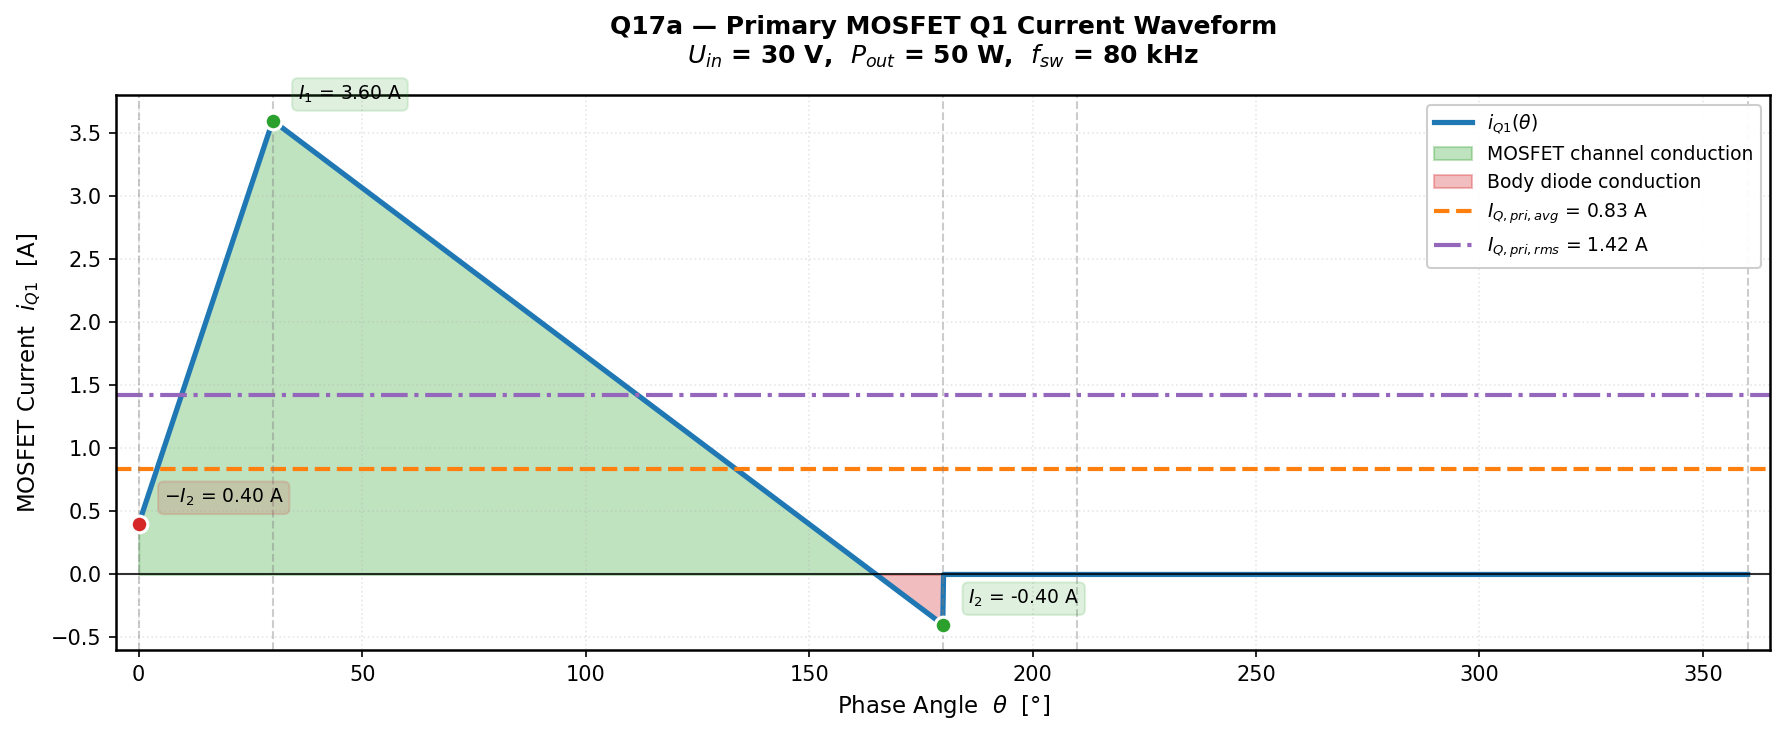

In [24]:
# === Q17a: Plot of Q1 current waveform ===

fig, ax = plt.subplots(figsize=(12, 5))

# Q1 current (conduction interval: 0 ≤ θ < π)
ax.plot(np.degrees(theta), i_Q1, linewidth=2.5, color="#1f77b4", label=r"$i_{Q1}(\theta)$")

# Shade MOSFET channel vs body diode conduction
ax.fill_between(np.degrees(theta), i_Q1, 0,
                where=(i_Q1 > 0), alpha=0.3, color="#2ca02c",
                label="MOSFET channel conduction")
ax.fill_between(np.degrees(theta), i_Q1, 0,
                where=(i_Q1 < 0), alpha=0.3, color="#d62728",
                label="Body diode conduction")

# Reference lines
ax.axhline(0, color="k", linewidth=1, alpha=0.8)
ax.axhline(I_Q_pri_avg, color="#ff7f0e", linestyle="--", linewidth=2,
           label=f"$I_{{Q,pri,avg}}$ = {I_Q_pri_avg:.2f} A")
ax.axhline(I_Q_pri_rms, color="#9467bd", linestyle="-.", linewidth=2,
           label=f"$I_{{Q,pri,rms}}$ = {I_Q_pri_rms:.2f} A")

# Key switching instants
for th_val, lbl in [(0, r"$0$"), (phi_wc, r"$\phi$"), (np.pi, r"$\pi$"),
                    (np.pi + phi_wc, r"$\pi+\phi$"), (2*np.pi, r"$2\pi$")]:
    ax.axvline(np.degrees(th_val), color="gray", linestyle="--", alpha=0.4, linewidth=1)

# Mark key current values on the waveform
for th_val, i_val, lbl, color in [
    (0, -I_2, f"$-I_2$ = {-I_2:.2f} A", "#d62728"),
    (phi_wc, I_1, f"$I_1$ = {I_1:.2f} A", "#2ca02c"),
    (np.pi, I_2, f"$I_2$ = {I_2:.2f} A", "#2ca02c"),
]:
    ax.plot(np.degrees(th_val), i_val, "o", color=color, markersize=8,
            markeredgecolor="white", markeredgewidth=1.5, zorder=5)
    ax.annotate(lbl, (np.degrees(th_val), i_val),
                textcoords="offset points", xytext=(12, 10), fontsize=9,
                bbox=dict(boxstyle="round,pad=0.3", facecolor=color, alpha=0.15,
                          edgecolor=color, linewidth=1))

ax.set_xlabel(r"Phase Angle  $\theta$  [°]", fontsize=11)
ax.set_ylabel(r"MOSFET Current  $i_{Q1}$  [A]", fontsize=11)
ax.set_title(f"Q17a — Primary MOSFET Q1 Current Waveform\n"
             f"$U_{{in}}$ = {U_in_min} V,  $P_{{out}}$ = {P_out_nom} W,  "
             f"$f_{{sw}}$ = {f_sw/1e3:.0f} kHz",
             fontsize=12, fontweight="bold", pad=15)
ax.legend(fontsize=9, loc="upper right", framealpha=0.95)
ax.grid(True, alpha=0.3, linestyle=":", linewidth=0.8)
ax.set_xlim(-5, 365)
fig.tight_layout()
plt.show()

## Q19 — Secondary Side MOSFET Current: Average & RMS

### Worst-case operating point
Same as Q17: **minimum input voltage** ($U_\mathrm{in,min}$) and **nominal output power** ($P_\mathrm{out,nom}$).

### MOSFET current waveform (Q5 — high-side, leg C, secondary bridge)

The secondary bridge switching function is:

$$s_2(\theta) = \begin{cases} -1 & 0 \le \theta < \phi \\ +1 & \phi \le \theta < \pi+\phi \\ -1 & \pi+\phi \le \theta < 2\pi \end{cases}$$

Q5 & Q8 conduct when $s_2 = +1$ (i.e., $\phi \le \theta < \pi + \phi$). The secondary winding current is $n \cdot i_L(\theta)$, so:

$$i_{Q5}(\theta) = \begin{cases} n \cdot i_L(\theta) & \phi \le \theta < \pi + \phi \\ 0 & \text{otherwise} \end{cases}$$

### Analytical RMS and Average

Within Q5's conduction interval:
- **Segment 1** ($\phi \le \theta < \pi$): current goes from $n I_1$ to $n I_2$
- **Segment 2** ($\pi \le \theta < \pi + \phi$): current goes from $n I_2$ to $-n I_1$

$$I_{Q,\mathrm{sec,avg}} = \frac{1}{2\pi}\left[\frac{\pi - \phi}{2}\,n(I_1 + I_2) + \frac{\phi}{2}\,n(I_2 - I_1)\right]$$

$$I_{Q,\mathrm{sec,rms}} = \sqrt{\frac{n^2}{2\pi}\left[\frac{\pi - \phi}{3}(I_1^2 + I_1 I_2 + I_2^2) + \frac{\phi}{3}(I_2^2 - I_2 I_1 + I_1^2)\right]}$$

In [25]:
# === Q19: Secondary Side MOSFET Current — Analytical Calculation ===
# Worst case: U_in = U_in_min, P_out = P_out_nom
# I_1, I_2, phi_min, n, theta, i_L already available

print("Q19: SECONDARY SIDE MOSFET CURRENT (Q5 — high-side, leg C)")
print("=" * 70)
print(f"\nWorst-case operating point:")
print(f"  U_in  = U_in,min = {U_in_min} V")
print(f"  P_out = P_out,nom = {P_out_nom} W")
print(f"  φ     = φ_min = {np.degrees(phi_wc):.2f}°  ({phi_wc:.4f} rad)")
print(f"  n     = {n:.4f}")
print(f"  I_1   = {I_1:.4f} A,   n·I_1 = {n*I_1:.4f} A")
print(f"  I_2   = {I_2:.4f} A,   n·I_2 = {n*I_2:.4f} A")

# --- Analytical Average ---
# Q5 conducts during φ ≤ θ < π+φ
# Segment 1: [φ, π]      →  i_sec = n·i_L goes from n·I_1 to n·I_2
# Segment 2: [π, π+φ]    →  i_sec = n·i_L goes from n·I_2 to -n·I_1

I_Q_sec_avg = (1 / (2 * np.pi)) * (
    ((np.pi - phi_wc) / 2) * n * (I_1 + I_2) +    # Seg 1: avg of (n·I_1, n·I_2)
    (phi_wc / 2) * n * (I_2 + (-I_1))              # Seg 2: avg of (n·I_2, -n·I_1)
)

# --- Analytical RMS ---
# ∫(a→b)² dθ = Δθ/3 × (a² + ab + b²)
I_Q_sec_rms_sq = (n**2 / (2 * np.pi)) * (
    ((np.pi - phi_wc) / 3) * (I_1**2 + I_1 * I_2 + I_2**2) +  # Seg 1: a=I_1, b=I_2
    (phi_wc / 3) * (I_2**2 - I_2 * I_1 + I_1**2)              # Seg 2: a=I_2, b=-I_1
)
I_Q_sec_rms = np.sqrt(I_Q_sec_rms_sq)

print(f"\n--- Analytical Results ---")
print(f"  I_Q,sec,avg = {I_Q_sec_avg:.2f} A")
print(f"  I_Q,sec,rms = {I_Q_sec_rms:.2f} A")

# --- Numerical verification ---
# Build Q5 current: conducts during φ ≤ θ < π+φ, carrying n·i_L
i_Q5 = np.where((theta >= phi_wc) & (theta < np.pi + phi_wc), n * i_L, 0.0)

I_Q_sec_avg_num = np.mean(i_Q5)
I_Q_sec_rms_num = np.sqrt(np.mean(i_Q5**2))

print(f"\n--- Numerical Verification ---")
print(f"  I_Q,sec,avg = {I_Q_sec_avg_num:.2f} A")
print(f"  I_Q,sec,rms = {I_Q_sec_rms_num:.2f} A")
print("=" * 70)

Q19: SECONDARY SIDE MOSFET CURRENT (Q5 — high-side, leg C)

Worst-case operating point:
  U_in  = U_in,min = 30 V
  P_out = P_out,nom = 50 W
  φ     = φ_min = 30.00°  (0.5236 rad)
  n     = 4.1667
  I_1   = 3.6000 A,   n·I_1 = 15.0000 A
  I_2   = -0.4000 A,   n·I_2 = -1.6667 A

--- Analytical Results ---
  I_Q,sec,avg = 2.08 A
  I_Q,sec,rms = 5.93 A

--- Numerical Verification ---
  I_Q,sec,avg = 2.08 A
  I_Q,sec,rms = 5.93 A


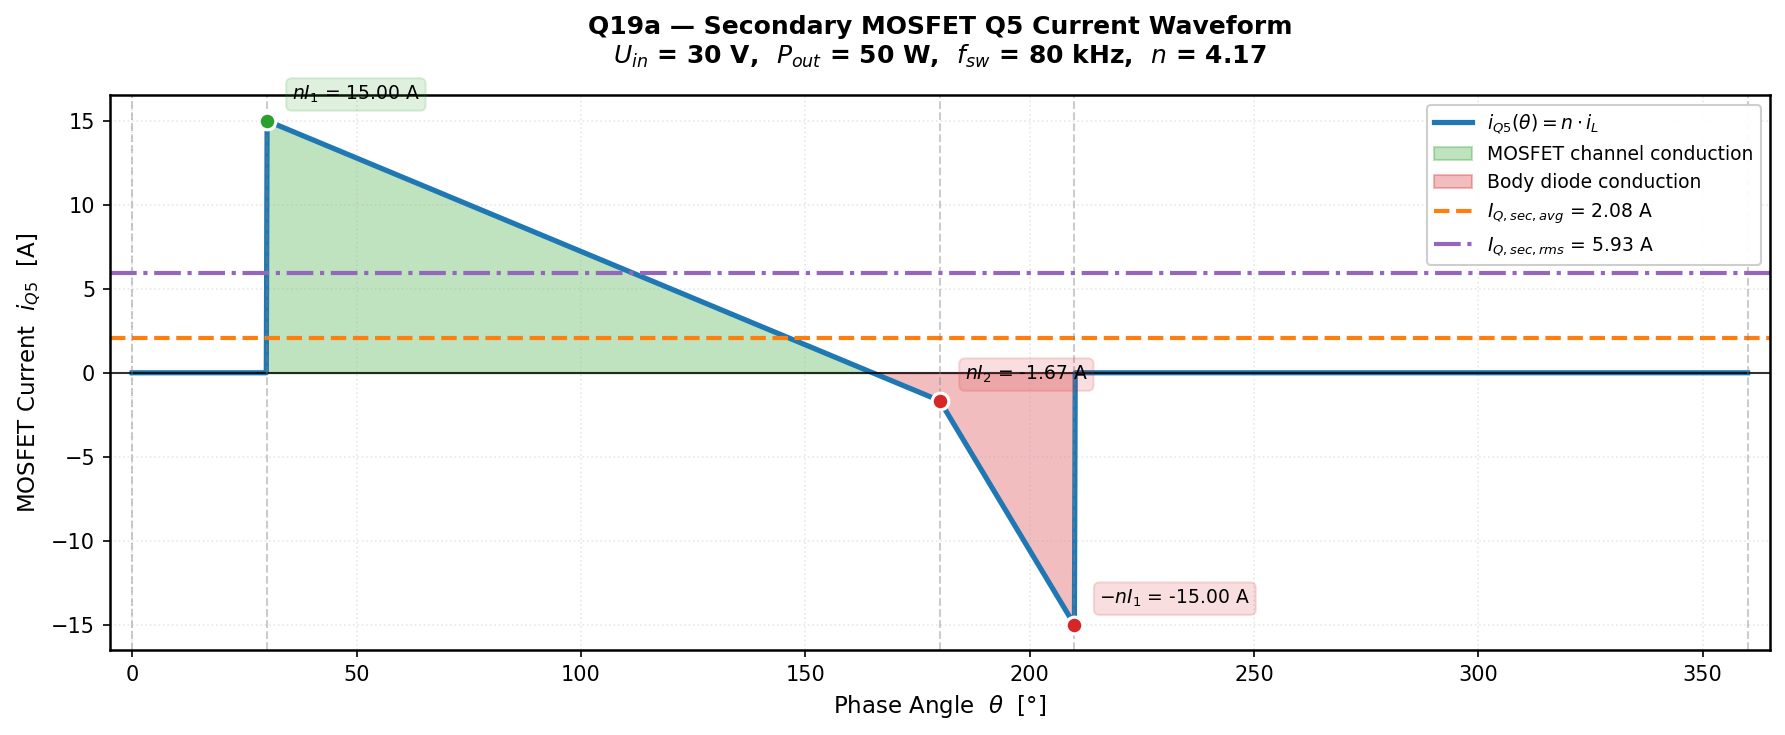

In [26]:
# === Q19a: Plot of Q5 current waveform ===

fig, ax = plt.subplots(figsize=(12, 5))

# Q5 current (conduction interval: φ ≤ θ < π+φ)
ax.plot(np.degrees(theta), i_Q5, linewidth=2.5, color="#1f77b4", label=r"$i_{Q5}(\theta) = n \cdot i_L$")

# Shade MOSFET channel vs body diode conduction
ax.fill_between(np.degrees(theta), i_Q5, 0,
                where=(i_Q5 > 0), alpha=0.3, color="#2ca02c",
                label="MOSFET channel conduction")
ax.fill_between(np.degrees(theta), i_Q5, 0,
                where=(i_Q5 < 0), alpha=0.3, color="#d62728",
                label="Body diode conduction")

# Reference lines
ax.axhline(0, color="k", linewidth=1, alpha=0.8)
ax.axhline(I_Q_sec_avg, color="#ff7f0e", linestyle="--", linewidth=2,
           label=f"$I_{{Q,sec,avg}}$ = {I_Q_sec_avg:.2f} A")
ax.axhline(I_Q_sec_rms, color="#9467bd", linestyle="-.", linewidth=2,
           label=f"$I_{{Q,sec,rms}}$ = {I_Q_sec_rms:.2f} A")

# Key switching instants
for th_val, lbl in [(0, r"$0$"), (phi_wc, r"$\phi$"), (np.pi, r"$\pi$"),
                    (np.pi + phi_wc, r"$\pi+\phi$"), (2*np.pi, r"$2\pi$")]:
    ax.axvline(np.degrees(th_val), color="gray", linestyle="--", alpha=0.4, linewidth=1)

# Mark key current values on the waveform
for th_val, i_val, lbl, color in [
    (phi_wc, n*I_1, f"$nI_1$ = {n*I_1:.2f} A", "#2ca02c"),
    (np.pi, n*I_2, f"$nI_2$ = {n*I_2:.2f} A", "#d62728"),
    (np.pi + phi_wc, -n*I_1, f"$-nI_1$ = {-n*I_1:.2f} A", "#d62728"),
]:
    ax.plot(np.degrees(th_val), i_val, "o", color=color, markersize=8,
            markeredgecolor="white", markeredgewidth=1.5, zorder=5)
    ax.annotate(lbl, (np.degrees(th_val), i_val),
                textcoords="offset points", xytext=(12, 10), fontsize=9,
                bbox=dict(boxstyle="round,pad=0.3", facecolor=color, alpha=0.15,
                          edgecolor=color, linewidth=1))

ax.set_xlabel(r"Phase Angle  $\theta$  [°]", fontsize=11)
ax.set_ylabel(r"MOSFET Current  $i_{Q5}$  [A]", fontsize=11)
ax.set_title(f"Q19a — Secondary MOSFET Q5 Current Waveform\n"
             f"$U_{{in}}$ = {U_in_min} V,  $P_{{out}}$ = {P_out_nom} W,  "
             f"$f_{{sw}}$ = {f_sw/1e3:.0f} kHz,  $n$ = {n:.2f}",
             fontsize=12, fontweight="bold", pad=15)
ax.legend(fontsize=9, loc="upper right", framealpha=0.95)
ax.grid(True, alpha=0.3, linestyle=":", linewidth=0.8)
ax.set_xlim(-5, 365)
fig.tight_layout()
plt.show()

## MOSFET Conduction Losses with Temperature Dependence

### Temperature-dependent $R_{DSon}$ (normalized datasheet value)

The datasheet provides a **normalized** $R_{DSon}$ curve as a function of junction temperature. The normalized value $R_{DSon,norm}(T_J)$ is read directly from the graph at the operating temperature.

$$R_{DSon}(T_J) = R_{DSon,max}(25^\circ C) \cdot R_{DSon,norm}(T_J)$$

### MOSFET Conduction Losses

$$P_{CM} = R_{DSon}(T_J) \cdot I_{Drms}^2$$

### Total Conduction Losses

Since the dead time is small, **diode losses are neglected**:

$$\boxed{P_C = P_{CM} = R_{DSon,max}(25^\circ C) \cdot R_{DSon,norm}(T_J) \cdot I_{Drms}^2}$$

In [36]:
# === Q44: MOSFET conduction losses (datasheet-based, temperature dependent) ===
# Diode losses neglected (small dead time).
# Normalised Rdson read directly from datasheet curve at operating Tj.

# -----------------------------
# USER INPUT (datasheet values)
# -----------------------------

# Primary MOSFET (Q1-type)
RDS_on_max_25_pri = 80e-3            # [Ohm] maximum Rdson at 25°C
Rdson_norm_pri    = 2             # [-] normalised Rdson at operating Tj (from datasheet)
Tj_pri_C          = 125              # [°C] operating junction temperature

# Secondary MOSFET (Q5-type)
RDS_on_max_25_sec = 3.2e-3           # [Ohm] maximum Rdson at 25°C
Rdson_norm_sec    = 2.5             # [-] normalised Rdson at operating Tj (from datasheet)
Tj_sec_C          = 125              # [°C] operating junction temperature

# -----------------------------
# Rdson at operating temperature
# -----------------------------
RDS_T_pri = RDS_on_max_25_pri * Rdson_norm_pri
RDS_T_sec = RDS_on_max_25_sec * Rdson_norm_sec

# -----------------------------
# Use currents from Q17 & Q19
# -----------------------------
# Channel current only (MOSFET conducts when i > 0)
I_Drms_pri = I_Q_pri_rms
I_Drms_sec = I_Q_sec_rms

# -----------------------------
# Conduction losses per device
# -----------------------------
P_C_pri = RDS_T_pri * I_Drms_pri**2
P_C_sec = RDS_T_sec * I_Drms_sec**2

print("=== PRIMARY MOSFET (per device) ===")
print(f"  RDS_on_max(25°C) = {RDS_on_max_25_pri*1e3:.1f} mΩ")
print(f"  Rdson_norm(Tj={Tj_pri_C}°C) = {Rdson_norm_pri}")
print(f"  RDS_on(Tj={Tj_pri_C}°C) = {RDS_T_pri*1e3:.3f} mΩ")
print(f"  Channel I_Drms = {I_Drms_pri:.4f} A")
print(f"  P_C = {P_C_pri:.4f} W")

print("\n=== SECONDARY MOSFET (per device) ===")
print(f"  RDS_on_max(25°C) = {RDS_on_max_25_sec*1e3:.1f} mΩ")
print(f"  Rdson_norm(Tj={Tj_sec_C}°C) = {Rdson_norm_sec}")
print(f"  RDS_on(Tj={Tj_sec_C}°C) = {RDS_T_sec*1e3:.3f} mΩ")
print(f"  Channel I_Drms = {I_Drms_sec:.4f} A")
print(f"  P_C = {P_C_sec:.4f} W")

# Bridge totals (4 MOSFETs per full bridge)
P_cond_pri = 4 * P_C_pri
P_cond_sec = 4 * P_C_sec
P_cond_total = P_cond_pri + P_cond_sec
print("\n=== BRIDGE TOTALS ===")
print(f"  Primary bridge (4 devices):   {P_cond_pri:.4f} W")
print(f"  Secondary bridge (4 devices): {P_cond_sec:.4f} W")
print(f"  Both bridges total:           {P_cond_total:.4f} W")

=== PRIMARY MOSFET (per device) ===
  RDS_on_max(25°C) = 80.0 mΩ
  Rdson_norm(Tj=125°C) = 2
  RDS_on(Tj=125°C) = 160.000 mΩ
  Channel I_Drms = 1.4236 A
  P_C = 0.3243 W

=== SECONDARY MOSFET (per device) ===
  RDS_on_max(25°C) = 3.2 mΩ
  Rdson_norm(Tj=125°C) = 2.5
  RDS_on(Tj=125°C) = 8.000 mΩ
  Channel I_Drms = 5.9317 A
  P_C = 0.2815 W

=== BRIDGE TOTALS ===
  Primary bridge (4 devices):   1.2971 W
  Secondary bridge (4 devices): 1.1259 W
  Both bridges total:           2.4230 W


## Q23 — Primary Side MOSFET Switching Losses

### ZVS Turn-On

The DAB converter is designed to always operate in **Zero Voltage Switching (ZVS)**. At turn-on, the body diode of the incoming MOSFET conducts first, clamping $V_{DS} \approx 0$. Therefore:

$$\boxed{P_{T,on} = 0}$$

### Turn-Off Losses 

At turn-off, the MOSFET channel is hard-switched off while carrying current. 

$$E_{off} = \frac{1}{2} \, V_{DS} \cdot I_{D} \cdot (t_{ru} + t_{fi})$$

where:
- $t_{ru}$: Voltage rise time (drain-source voltage rises to $V_{DS}$)
- $t_{fi}$: Current fall time (drain current falls to 0)

### 1. Voltage Rise Time ($t_{ru}$)
The voltage rise time can be approximated by : 

$$t_{ru} = \frac{t_{ru,1}+t_{ru,2}}{2}$$

$$I_{G,off}=\frac{U_{platteau}}{R_{G}}$$

$$t_{ru1}=(U_{DD}-I_{D,on}\cdot R_{DS,on}\ ) \frac{C_{GD1}}{I_{G,off}}$$

$$t_{ru2}=(U_{DD}-I_{D,on}\cdot R_{DS,on}\ ) \frac{C_{GD2}}{I_{G,off}}$$

$$ \Rightarrow t_{ru} = \frac{(U_{DD}-I_{D,on}\cdot R_{DS,on}\ )}{2\,I_{G,off}} (C_{GD1}+C_{GD2})$$

wehre $C_{GD1}$ and $C_{GD2}$ are the gate-drain capacitances at the initial and final voltage levels, which can be read from the datasheet (callded $C_{rss}$).


### 2. Current Fall Time ($t_{fi}$)
The current rise and fall time can directly be read from the datasheet.

### Worst case conditions:

**First stage:** the longer the two rise times are, the higher the turn-off losses. The input voltage only changes the voltage rise time. $U_{DD}$ and $I_{D,on}$ are the main factors affecting the voltage rise time. The worst case is at maximum input voltage, where $U_{DD}$ is highest and $I_{D,on}$ is lowest (due to higher reflected output voltage), leading to the longest voltage rise time.(see plot below)

**Second stage:** the longer the current fall time is, the higher the turn-off losses. The current fall time is mainly affected by the current level. $U_{DD}$ The worst case is at minimum input voltage, where the current is highest, leading to the longest current fall time.

### Total Turn-Off Power
Each MOSFET switches off once per period $T_{sw}$:

$$\boxed{P_{T,off} = E_{off} \cdot f_{sw}}$$

In [37]:
# === Q23: Primary Side MOSFET Switching Losses (using formulas from previous cell) ===
# ZVS -> P_T,on = 0
# E_off = 0.5 * V_DS,swing * I_D,on * (t_ru + t_fi)

R_G = 5.0           # [Ohm] external gate resistance (given)
V_GS_drive = 12.0       # [V] gate drive voltage (given)

#############################
## FIRST STAGE PARAMETERS: ##
#############################

# -----------------------------------------------
# USER INPUT: Primary MOSFET datasheet values
# -----------------------------------------------

U_plateau_prim = 5.0         # [V] gate plateau voltage
C_GD1_prim     = 500e-12  # [F] C_gd at low V_DS (from C_rss curve)
C_GD2_prim   = 55e-12      # [F] C_gd at high V_DS (from C_rss curve)

t_fi_prim = 12e-9            # [s] current fall time from datasheet (set your exact value)

# -----------------------------------------------
# Worst-case Operating Point (analytically determined)
# -----------------------------------------------
U_in_wc_prim  = U_in_max      # [V] U_DD worst-case  (60 V)
P_out_wc = P_out_nom     # [W]

phi_wc_op_prim = phase_shift_for_power(P_out_wc, U_in_wc_prim, U_out, n, f_sw, L)
d_wc_op_prim   = n * U_out / U_in_wc_prim

# Turn-off current at theta = pi
I_D_on_prim = (U_in_wc_prim / (2 * omega * L)) * (2 * d_wc_op_prim * phi_wc_op_prim + (1 - d_wc_op_prim) * np.pi)

##############################
## SECOND STAGE PARAMETERS: ##
##############################

# -----------------------------------------------
# USER INPUT: Secondary MOSFET datasheet values
# -----------------------------------------------

U_plateau_sec = 3.15         # [V] gate plateau voltage
C_GD1_sec     = 700e-12      # [F] C_gd at low V_DS (from C_rss curve)
C_GD2_sec     = 200e-12      # [F] C_gd at high V_DS (from C_rss curve)

t_fi_sec = 36e-9            # [s] current fall time from datasheet (set your exact value)

# -----------------------------------------------
# Worst-case Operating Point (analytically determined)
# -----------------------------------------------
U_in_wc_sec  = U_in_min  # [V] U_DD worst-case 
P_out_wc = P_out_nom     # [W]

phi_wc_op_sec = phase_shift_for_power(P_out_wc, U_in_wc_sec, U_out, n, f_sw, L)
d_wc_op_sec   = n * U_out / U_in_wc_sec

# Turn-off current at theta = pi
#I_D_on_sec = (U_in_wc_sec / (2 * omega * L)) * (2 * d_wc_op_sec * phi_wc_op_sec + (1 - d_wc_op_sec) * np.pi)

I_D_on_sec = 15.1 # [A] (from simualtions)

def switching_losses(C_GD1, 
                     C_GD2, 
                     U_plateau, 
                     t_fi,
                     U_in_wc,
                     phi_wc_op,
                     R_DS_on,
                     I_D_on):
    # -----------------------------------------------
    # Voltage-rise time from your formulas
    # -----------------------------------------------
    I_G_off   = U_plateau / R_G

    V_DS_swing = U_in_wc - R_DS_on * I_D_on

    # t_ru1 = (U_DD - I_D,on * R_DS,on) * C_GD1 / I_G,off
    # t_ru2 = (U_DD - I_D,on * R_DS,on) * C_GD2 / I_G,off
    # t_ru  = (t_ru1 + t_ru2) / 2
    t_ru1 = V_DS_swing * C_GD1 / I_G_off
    t_ru2 = V_DS_swing * C_GD2 / I_G_off
    t_ru  = 0.5 * (t_ru1 + t_ru2)

    # -----------------------------------------------
    # Switching energy and power
    # -----------------------------------------------
    P_Ton_wc  = 0.0
    E_off_wc  = 0.5 * V_DS_swing * I_D_on * (t_ru + t_fi)
    P_Toff_wc = E_off_wc * f_sw

    print(f"Worst-case operating point (analytical): U_DD = {U_in_wc:.1f} V, P_out = {P_out_wc:.1f} W")
    print(f"phi = {np.degrees(phi_wc_op):.2f} deg")
    print(f"I_D,on = I_2 = {I_D_on:.4f} A")
    print(f"R_DS,on(Tj) = {R_DS_on*1e3:.3f} mOhm")
    print(f"V_DS,swing = U_DD - R_DS,on*I_D,on = {V_DS_swing:.4f} V")

    print("\n--- Time Components ---")
    print(f"R_Gate = {R_G:.2f} Ohm")
    print(f"I_G,off = U_plateau / R_G,total = {I_G_off:.4f} A")
    print(f"C_GD1 = {C_GD1*1e12:.2f} pF, C_GD2 = {C_GD2*1e12:.2f} pF")
    print(f"t_ru1 = {t_ru1*1e9:.3f} ns")
    print(f"t_ru2 = {t_ru2*1e9:.3f} ns")
    print(f"t_ru  = (t_ru1+t_ru2)/2 = {t_ru*1e9:.3f} ns")
    print(f"t_fi  = {t_fi*1e9:.3f} ns")

    print("\n--- Switching Losses ---")
    print(f"P_T,on  = {P_Ton_wc:.4f} W (ZVS)")
    print(f"E_off   = 0.5*V_DS,swing*I_D,on*(t_ru+t_fi) = {E_off_wc*1e6:.4f} uJ")
    print(f"P_T,off = E_off * f_sw = {P_Toff_wc:.4f} W")
    print(f"Primary bridge total (4 devices): {4*P_Toff_wc:.4f} W")

    return 4*P_Toff_wc

print("=== Q23 RESULTS — PRIMARY MOSFET SWITCHING LOSSES ===")
P_switching_prim = switching_losses(
    C_GD1=C_GD1_prim, 
    C_GD2=C_GD2_prim, 
    U_plateau=U_plateau_prim, 
    t_fi=t_fi_prim,
    U_in_wc=U_in_wc_prim,
    phi_wc_op=phi_wc_op_prim,
    R_DS_on=RDS_T_pri,
    I_D_on = I_D_on_prim
)
print("=== Q24 RESULTS — SECONDARY MOSFET SWITCHING LOSSES ===")
P_switching_sec = switching_losses(
    C_GD1=C_GD1_sec, 
    C_GD2=C_GD2_sec, 
    U_plateau=U_plateau_sec, 
    t_fi=t_fi_sec,
    U_in_wc=U_in_wc_sec,  # Same U_DD for secondary side
    phi_wc_op=phi_wc_op_sec,  # Same phase shift for worst-case
    R_DS_on=RDS_T_sec,
    I_D_on = I_D_on_sec
)

P_switching_total = P_switching_prim + P_switching_sec
print("\n=== SUMMARY OF LOSSES ===")
print(f"Primary bridge switching losses:   {P_switching_prim:.4f} W")
print(f"Secondary bridge switching losses: {P_switching_sec:.4f} W")
print(f"Total switching losses:            {P_switching_total:.4f} W")

=== Q23 RESULTS — PRIMARY MOSFET SWITCHING LOSSES ===
Worst-case operating point (analytical): U_DD = 60.0 V, P_out = 50.0 W
phi = 13.51 deg
I_D,on = I_2 = 2.1010 A
R_DS,on(Tj) = 160.000 mOhm
V_DS,swing = U_DD - R_DS,on*I_D,on = 59.6638 V

--- Time Components ---
R_Gate = 5.00 Ohm
I_G,off = U_plateau / R_G,total = 1.0000 A
C_GD1 = 500.00 pF, C_GD2 = 55.00 pF
t_ru1 = 29.832 ns
t_ru2 = 3.282 ns
t_ru  = (t_ru1+t_ru2)/2 = 16.557 ns
t_fi  = 12.000 ns

--- Switching Losses ---
P_T,on  = 0.0000 W (ZVS)
E_off   = 0.5*V_DS,swing*I_D,on*(t_ru+t_fi) = 1.7898 uJ
P_T,off = E_off * f_sw = 0.1432 W
Primary bridge total (4 devices): 0.5727 W
=== Q24 RESULTS — SECONDARY MOSFET SWITCHING LOSSES ===
Worst-case operating point (analytical): U_DD = 30.0 V, P_out = 50.0 W
phi = 30.00 deg
I_D,on = I_2 = 15.1000 A
R_DS,on(Tj) = 8.000 mOhm
V_DS,swing = U_DD - R_DS,on*I_D,on = 29.8792 V

--- Time Components ---
R_Gate = 5.00 Ohm
I_G,off = U_plateau / R_G,total = 0.6300 A
C_GD1 = 700.00 pF, C_GD2 = 200.00 pF
t_r

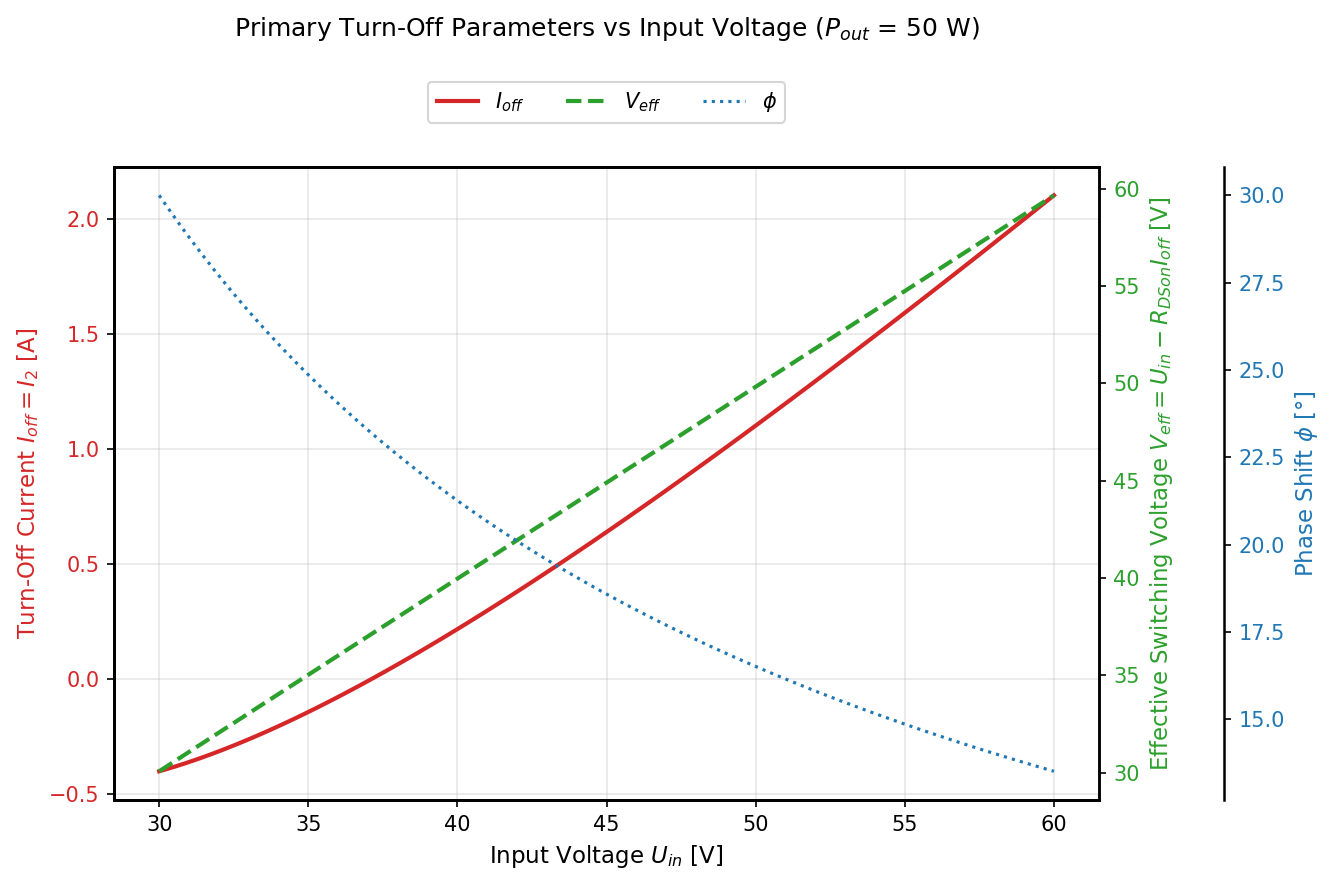

In [42]:
# === Plot: Primary Turn-Off Current & Effective Voltage vs Input Voltage ===
# Plot I_off (which is I_2) over the full input voltage range at nominal power
# Also plot the effective voltage V_DS,off = U_in - R_DSon * I_off

# 1. Sweep input voltage
U_in_sweep = np.linspace(U_in_min, U_in_max, 100)

# 2. Calculate phase shift, I_2 (turn-off current), and V_DS,off for each U_in
I_off_sweep    = []
V_ds_off_sweep = []
phi_sweep      = []

for U_val in U_in_sweep:
    # Phase shift required for nominal power
    phi_val = phase_shift_for_power(P_out_nom, U_val, U_out, n, f_sw, L)
    
    # Calculate I_2 at this operating point
    d_val = n * U_out / U_val
    # I_2 formula: (V1 / 2*w*L) * (2*d*phi + (1-d)*pi)
    # Here V1 = U_val
    I2_val = (U_val / (2 * omega * L)) * (2 * d_val * phi_val + (1 - d_val) * np.pi)
    
    # Effective switching voltage (V_swing)
    # The voltage across the switch rises from V_DS(on) = R_DSon * I2 to U_in
    # V_swing = U_in - R_DSon * I2
    V_ds_off_val = U_val - RDS_T_pri * I2_val

    phi_sweep.append(phi_val)
    I_off_sweep.append(I2_val)
    V_ds_off_sweep.append(V_ds_off_val)

I_off_sweep    = np.array(I_off_sweep)
V_ds_off_sweep = np.array(V_ds_off_sweep)
phi_sweep      = np.array(phi_sweep)

# 3. Plot
fig, ax1 = plt.subplots(figsize=(9, 6))

# Axis 1: Turn-off Current
color = 'tab:red'
ax1.set_xlabel(r'Input Voltage $U_{in}$ [V]', fontsize=11)
ax1.set_ylabel(r'Turn-Off Current $I_{off}=I_2$ [A]', color=color, fontsize=11)
ax1.plot(U_in_sweep, I_off_sweep, color=color, linewidth=2, label=r'$I_{off}$')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, alpha=0.3)

# Axis 2: Effective Switching Voltage
ax2 = ax1.twinx()
color = 'tab:green'
ax2.set_ylabel(r'Effective Switching Voltage $V_{eff} = U_{in} - R_{DSon}I_{off}$ [V]', color=color, fontsize=11)
ax2.plot(U_in_sweep, V_ds_off_sweep, color=color, linewidth=2, linestyle='--', label=r'$V_{eff}$')
ax2.tick_params(axis='y', labelcolor=color)

# Axis 3: Phase Shift (offset to the right)
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))
color = 'tab:blue'
ax3.set_ylabel(r'Phase Shift $\phi$ [°]', color=color, fontsize=11)
ax3.plot(U_in_sweep, np.degrees(phi_sweep), color=color, linestyle=':', linewidth=1.5, label=r'$\phi$')
ax3.tick_params(axis='y', labelcolor=color)

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()
ax1.legend(lines1 + lines2 + lines3, labels1 + labels2 + labels3, loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=3)

plt.title(f"Primary Turn-Off Parameters vs Input Voltage ($P_{{out}}$ = {P_out_nom} W)\n\n", fontsize=12, pad=35)
fig.tight_layout()
plt.show()

## Q25 - Semicunductor Efficiency at Nominal Conditions

Only the semconductor conduction and switching losses are considered, relative to the nominal output power. For both stages, the worst-case conidtions are used, which are not the same for the first and the second stage.

$$\eta = 1 - \frac{P_{C,pri} + P_{T,pri} + P_{C,sec} + P_{T,sec}}{P_{nom}}$$

In [ ]:
P_semic_losses = P_switching_total + P_cond_total

efficiency = 1 - P_semic_losses / P_out_nom
print(f"\nEstimated total semiconductor losses: {P_semic_losses:.4f} W")
print(f"Estimated efficiency at nominal power: {efficiency*100:.2f}%")


Estimated total semiconductor losses: 7.1352 W
Estimated efficiency at nominal power: 85.73
